In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import torch 
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
import copy
import mytools
import os, random


# Print and store device being used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


# Define important parameters

In [2]:
# Number of class in invariant mass used by the adversary
Num_classes = 10
# Hyper-parameter for adversarial training of the classifier
lambda_ = 6.0

run = 1


def seed_everything(seed: int = 0):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(int(42))

# Load and setup the data

In [3]:
# Read tritrig, wab, phiKK, and data files
df_tritrig = pd.read_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_tritrig_QualCuts.pk')
df_tritrig['PhiKK'] = 0.0
df_phiKK = pd.read_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_phiKK_QualCuts.pk')
df_phiKK['PhiKK'] = 1.0
df_wab = pd.read_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_wab_QualCuts.pk')
df_wab['PhiKK'] = 0.0 # Add label


print("tritrig: ", len(df_tritrig))
print("phiKK: ", len(df_phiKK))
print("wab: ", len(df_wab))


tritrig:  120352
phiKK:  3845
wab:  6580


In [4]:
# Make Training set with 20000 tritrig, 4000 phiKK, 4000 wab
tritrig_train = df_tritrig[0:20000]
wab_train = df_wab[0:3000]
phiKK_train = df_phiKK[0:3000]

# Combine and shuffle all training data
df_train = pd.concat([tritrig_train, phiKK_train, wab_train], ignore_index=True, sort=False)
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

# Get edges in invariant mass classes for one-hot encoding
# To be used for adverserial labels
# The edges are chosen such that each bin has equal number of background events
one_hot_edges = mytools.get_one_hot_edges(mytools.get_InvM( pd.concat([df_tritrig, df_wab], ignore_index=True, sort=False) ), n_bins=Num_classes)

# Split the training data into training and validation sets
df_train, df_val = train_test_split(df_train, test_size=0.33, random_state=42)

# Make X and y for training and validation sets
# the adverserial network has its own labels
X_train = df_train.drop(columns=['PhiKK'])
y_train = df_train['PhiKK']
y_adv_train = mytools.get_adv_labels( mytools.get_InvM(df_train), one_hot_edges)
X_val = df_val.drop(columns=['PhiKK'])
y_val = df_val['PhiKK']
y_adv_val = mytools.get_adv_labels( mytools.get_InvM(df_val), one_hot_edges)

# Make testing set with remaining events
tritrig_test = df_tritrig[20000:]
tritrig_test['type']= 'tritrig'
wab_test = df_wab[3000:]
wab_test['type']= 'wab'
phiKK_test = df_phiKK[3000:]
phiKK_test['type']= 'phiKK'

df_test = pd.concat([tritrig_test, phiKK_test,wab_test], ignore_index=True, sort=False)
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True) # Now shuffle the combined dataframe

X_test = df_test.drop(columns=['PhiKK','type'])
y_test = df_test['PhiKK']
y_adv_test = mytools.get_adv_labels( mytools.get_InvM(df_test), one_hot_edges)

df_test["InvM"] = mytools.get_InvM(df_test) 



/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_55350/1157922432.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tritrig_test['type']= 'tritrig'
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_55350/1157922432.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wab_test['type']= 'wab'
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_55350/1157922432.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

## Setup dataloaders

In [5]:
bsize = 2000

# Convert to tensor dataset and dataloader
train_dataset = TensorDataset(torch.from_numpy(X_train.to_numpy().astype(np.float32))  , torch.from_numpy(y_train.to_numpy().astype(np.float32)).unsqueeze(1)  )
train_loader = DataLoader(train_dataset, batch_size=bsize, shuffle=True)

val_dataset = TensorDataset(torch.from_numpy(X_val.to_numpy().astype(np.float32))  , torch.from_numpy(y_val.to_numpy().astype(np.float32)).unsqueeze(1)  )
val_loader = DataLoader(val_dataset, batch_size=bsize, shuffle=True)

test_dataset = TensorDataset(torch.from_numpy(X_test.to_numpy().astype(np.float32)))
test_loader = DataLoader(test_dataset, batch_size=bsize, shuffle=False)


## Initialize model, objective function, and optimizer

In [6]:
clas = mytools.Classifier(in_features=X_train.shape[1]).to(device)
criterion_clas = nn.BCEWithLogitsLoss()
optimizer_clas = optim.Adam(clas.parameters(), lr=1e-5)
scheduler_clas = torch.optim.lr_scheduler.ExponentialLR(optimizer_clas, gamma=0.9999)


## Pre-train the classifier

In [7]:
# Implement early stopping in training loop
# Stop if validation loss has not decreased for the last [patience] epochs
# The model with the lowest loss is stored
patience = 10

Training_losses = np.array([])
Validation_losses = np.array([])

epochs = 4000
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    
    Training_losses = np.append(Training_losses, mytools.train_clas(train_loader, clas, criterion_clas, optimizer_clas, scheduler_clas, device))
    Validation_losses = np.append(Validation_losses, mytools.validate_clas(val_loader, clas, criterion_clas, device))
    
    # Keep a running copy of the model with the lowest loss
    if Validation_losses[-1] == np.min(Validation_losses):
        final_classifier = copy.deepcopy(clas)
    
    if len(Validation_losses) > patience:
        if np.sum((Validation_losses[-1*np.arange(patience)-1] - Validation_losses[-1*np.arange(patience)-2]) < 0) == 0:
            print("Stopping early!")
            break
            
print("Done!")

Epoch 1
-------------------------------
Training loss: 0.594816
Validation loss: 0.636822 

Epoch 2
-------------------------------
Training loss: 0.571729
Validation loss: 0.604370 

Epoch 3
-------------------------------
Training loss: 0.556770
Validation loss: 0.591739 

Epoch 4
-------------------------------
Training loss: 0.545188
Validation loss: 0.593479 

Epoch 5
-------------------------------
Training loss: 0.536737
Validation loss: 0.601466 

Epoch 6
-------------------------------
Training loss: 0.531457
Validation loss: 0.586137 

Epoch 7
-------------------------------
Training loss: 0.524677
Validation loss: 0.557514 

Epoch 8
-------------------------------
Training loss: 0.521066
Validation loss: 0.536597 

Epoch 9
-------------------------------
Training loss: 0.515895
Validation loss: 0.526198 

Epoch 10
-------------------------------
Training loss: 0.510863
Validation loss: 0.511706 

Epoch 11
-------------------------------
Training loss: 0.507133
Validation los

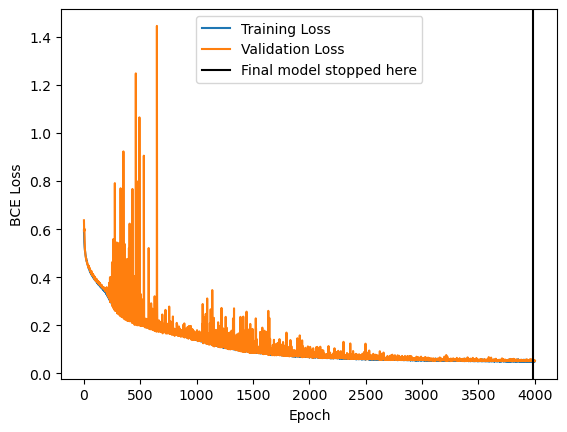

In [8]:
# Plot Training and Validation Loss
# Indicate where the final model stopped training

best_epoch = np.argmin(Validation_losses)+1

plt.plot(np.arange(len(Training_losses))+1,Training_losses,label="Training Loss")
plt.plot(np.arange(len(Validation_losses))+1,Validation_losses,label="Validation Loss")
plt.axvline(best_epoch,label="Final model stopped here",color='k')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
#plt.yscale('log')
plt.legend()

Test AUROC: 0.9963


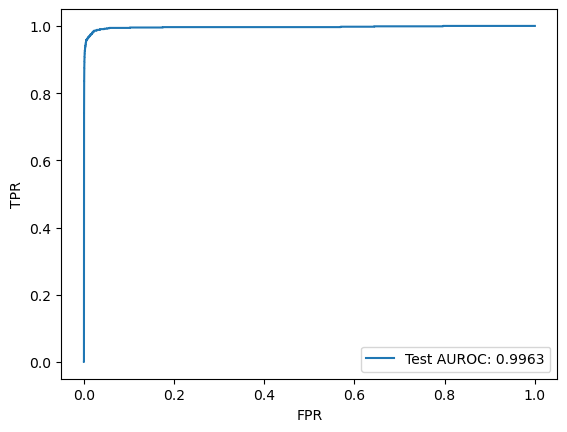

In [9]:
# Now test the pretrained model
test_pred = mytools.test_clas(test_loader, final_classifier, device)
test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

In [10]:
# Store the pretrained classifier labels
df_test["Class_pre"] = test_pred

# Save the pretrained classifier model
#torch.save(final_classifier.state_dict(), "/Users/mghrear/data/ML_data/patch/pretrained_classifier_2021_v9_pass5_run"+str(run)+"_limited.pt")


# Setup the adversary model

## Initialize model, objective function, and optimizer

In [11]:
adv = mytools.Adversary_small(n_classes=Num_classes).to(device)
criterion_adv = nn.CrossEntropyLoss(reduction='none')  # returns loss per sample so we can weight it
opt_adv = torch.optim.Adam(adv.parameters(), lr=1e-5)
scheduler_adv = torch.optim.lr_scheduler.ExponentialLR(opt_adv, gamma=0.999)


## Setup dataloaders

In [12]:
# Convert to tensor dataset and dataloader

# the structure is: feature, adversary label, weight
# The wight is 1 for tritrig and wab, and 0 for phiKK, to prevent the adversary from learning on phiKK events

train_adv_dataset = TensorDataset(torch.from_numpy(X_train.to_numpy() .astype(np.float32))  , torch.from_numpy(y_adv_train), (torch.from_numpy(y_train.to_numpy().astype(np.float32))==0).float())
train_adv_loader = DataLoader(train_adv_dataset, batch_size=bsize, shuffle=True)

val_adv_dataset = TensorDataset(torch.from_numpy(X_val.to_numpy() .astype(np.float32))  , torch.from_numpy(y_adv_val), (torch.from_numpy(y_val.to_numpy().astype(np.float32))==0).float() )
val_adv_loader = DataLoader(val_adv_dataset, batch_size=bsize, shuffle=True)

# Weights are not relavent for testing
test_adv_dataset = TensorDataset(torch.from_numpy(X_test.to_numpy() .astype(np.float32))  , torch.from_numpy(y_adv_test))
test_adv_loader = DataLoader(test_adv_dataset, batch_size=bsize, shuffle=True)

## Pre-train the adversary leaving classifier weights fixed

In [13]:
# Implement early stopping in training loop
# Stop if validation loss has not decreased for the last [patience] epochs
# The model with the lowest loss is stored


Training_losses = np.array([])
Validation_losses = np.array([])

epochs = 1000
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    
    Training_losses = np.append(Training_losses, mytools.train_adv(train_adv_loader, final_classifier, adv, criterion_adv, opt_adv, scheduler_adv, device))
    Validation_losses = np.append(Validation_losses, mytools.validate_adv(val_adv_loader, final_classifier, adv, criterion_adv, device))
    
    # Keep a running copy of the model with the lowest loss
    if Validation_losses[-1] == np.min(Validation_losses):
        final_adv = copy.deepcopy(adv)

print("Done!")

Epoch 1
-------------------------------
Training loss: 2.838951
Validation loss: 2.809882 

Epoch 2
-------------------------------
Training loss: 2.830789
Validation loss: 2.817323 

Epoch 3
-------------------------------
Training loss: 2.821330
Validation loss: 2.794898 

Epoch 4
-------------------------------
Training loss: 2.814999
Validation loss: 2.798691 

Epoch 5
-------------------------------
Training loss: 2.805206
Validation loss: 2.770489 

Epoch 6
-------------------------------
Training loss: 2.796980
Validation loss: 2.778707 

Epoch 7
-------------------------------
Training loss: 2.788772
Validation loss: 2.764206 

Epoch 8
-------------------------------
Training loss: 2.780080
Validation loss: 2.772027 

Epoch 9
-------------------------------
Training loss: 2.773838
Validation loss: 2.761697 

Epoch 10
-------------------------------
Training loss: 2.765379
Validation loss: 2.737337 

Epoch 11
-------------------------------
Training loss: 2.758278
Validation los

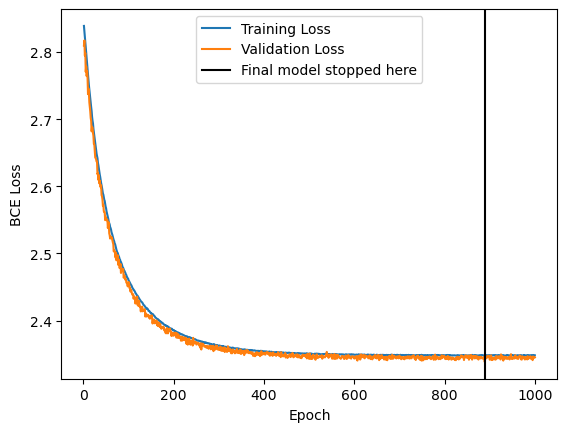

In [14]:
# Plot Training and Validation Loss
# Indicate where the final model stopped training

best_epoch = np.argmin(Validation_losses)+1

plt.plot(np.arange(len(Training_losses))+1,Training_losses,label="Training Loss")
plt.plot(np.arange(len(Validation_losses))+1,Validation_losses,label="Validation Loss")
plt.axvline(best_epoch,label="Final model stopped here",color='k')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.legend()

## Test the pre-trained adversary

class 0 test auc score: 0.49967645481524864
class 1 test auc score: 0.5033127065726177
class 2 test auc score: 0.4986503858558011
class 3 test auc score: 0.4998450686433402
class 4 test auc score: 0.49873098245922376
class 5 test auc score: 0.4996716464485643
class 6 test auc score: 0.5020304907704735
class 7 test auc score: 0.5046056415781334
class 8 test auc score: 0.4964356675273003
class 9 test auc score: 0.4968508549462668
average score:  0.49998098996169693


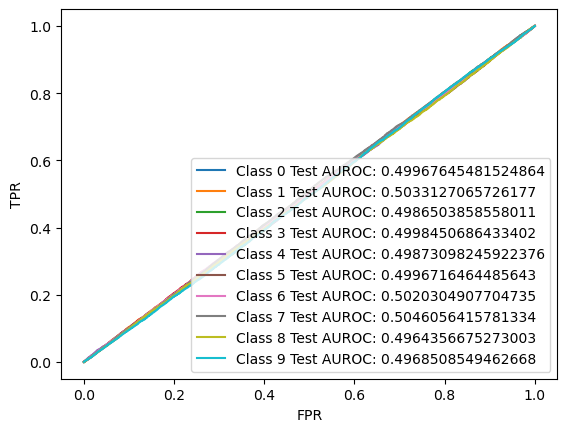

In [15]:

adv_test_pred = mytools.test_adv(test_adv_loader, final_classifier, final_adv, Num_classes, device)
adv_test_pred = torch.softmax(torch.tensor(adv_test_pred),dim=1).numpy()
score=0

for i in range(adv_test_pred.shape[1]):
    fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_adv_test[:,i], adv_test_pred[:,i], pos_label=1)
    auc_test = sklearn.metrics.auc(fpr, tpr)
    print("class " + str(i)+ " test auc score: " + str(auc_test))

    plt.plot(fpr, tpr, label='Class '+str(i)+' Test AUROC: '+str(auc_test))
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.legend()

    score += auc_test

print("average score: ", score/adv_test_pred.shape[1])

# Train full adverserial neural network

# Setup dataloaders

In [16]:
# the structure is: feature, classifier label, adversary label, weight
# The wight is 1 for tritrig and wab, and 0 for phiKK, to prevent the adversary from learning on phiKK events

train_full_dataset = TensorDataset(torch.from_numpy(X_train.to_numpy().astype(np.float32))  , torch.from_numpy(y_train.to_numpy().astype(np.float32)).unsqueeze(1), torch.from_numpy(y_adv_train),  (torch.from_numpy(y_train.to_numpy().astype(np.float32))==0).float())
train_full_loader = DataLoader(train_full_dataset, batch_size=bsize, shuffle=True)

val_full_dataset = TensorDataset(torch.from_numpy(X_val.to_numpy().astype(np.float32))  , torch.from_numpy(y_val.to_numpy().astype(np.float32)).unsqueeze(1),  torch.from_numpy(y_adv_val),  (torch.from_numpy(y_val.to_numpy().astype(np.float32))==0).float())
val_full_loader = DataLoader(val_full_dataset, batch_size=bsize, shuffle=True)


## Define loss functions

In [17]:
BCE_loss = nn.BCEWithLogitsLoss()
CE_loss = nn.CrossEntropyLoss(reduction='none') # returns loss per sample so we can weight it

def full_loss(output_clas, output_adv, target_clas, target_adv, w, lambda_):

    loss1 = BCE_loss(output_clas, target_clas )  # classification loss
    sample_losses2 = CE_loss(output_adv, target_adv)  # adversarial losses, since we set reduction='none', this is now a vector of losses, one per sample in the batch

    # Weighted mean loss over non-zero weights
    nonzero = w > 0
    loss2 = (sample_losses2[nonzero] * w[nonzero]).sum() / w[nonzero].sum()

    loss = loss1 - lambda_*loss2

    return loss
    


## Setup optimizers

In [18]:
optimizer_clas = optim.Adam(final_classifier.parameters(), lr=1e-7,betas=(0.9, 0.999))
optimizer_adv = optim.Adam(final_adv.parameters(), lr=2e-6,betas=(0.9, 0.999))

scheduler_clas = torch.optim.lr_scheduler.ExponentialLR(optimizer_clas, gamma=0.999)
scheduler_adv = torch.optim.lr_scheduler.ExponentialLR(optimizer_adv, gamma=0.999)

## Adversarial training

Epoch 1
-------------------------------
Classifier training loss: -14.034399
Adversary training loss: 2.348245
Classifier validation loss: -13.997789
Adversary validation loss: 2.341738
Diff score: 2.077821


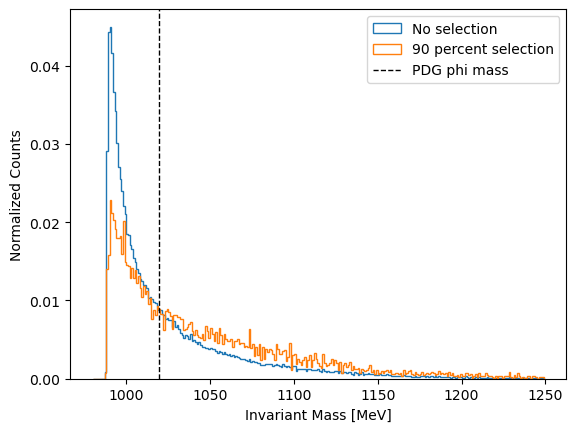

Epoch 2
-------------------------------
Classifier training loss: -14.016287
Adversary training loss: 2.344812
Classifier validation loss: -13.999739
Adversary validation loss: 2.342024
Diff score: 1.925117


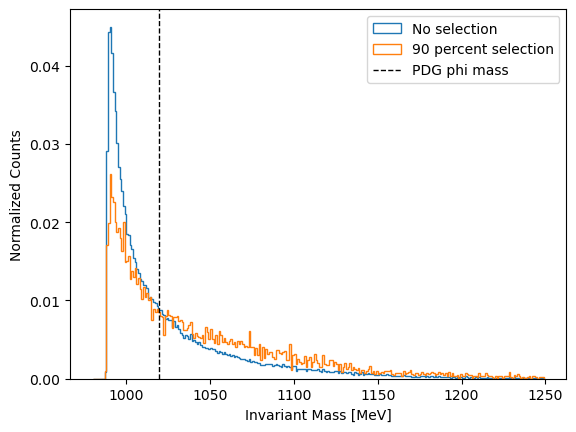

Epoch 3
-------------------------------
Classifier training loss: -14.004179
Adversary training loss: 2.342338
Classifier validation loss: -13.958443
Adversary validation loss: 2.335161
Diff score: 1.855308


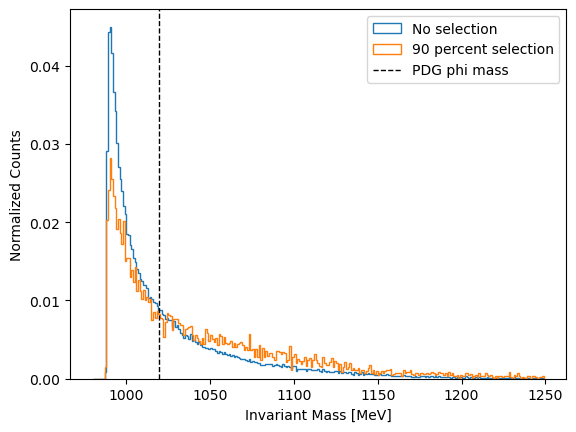

Epoch 4
-------------------------------
Classifier training loss: -13.988226
Adversary training loss: 2.339918
Classifier validation loss: -13.935819
Adversary validation loss: 2.331815
Diff score: 1.714708


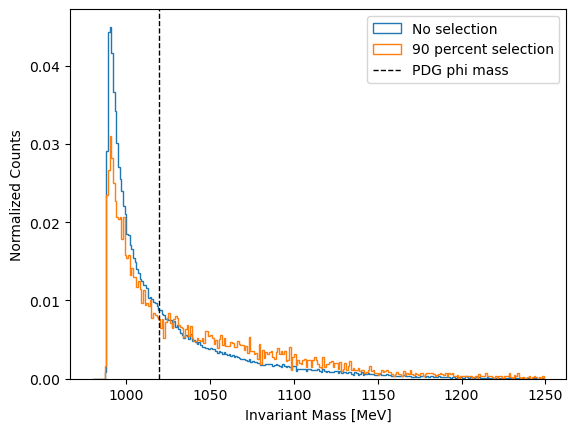

Epoch 5
-------------------------------
Classifier training loss: -13.974194
Adversary training loss: 2.337400
Classifier validation loss: -13.949925
Adversary validation loss: 2.333949
Diff score: 1.653034


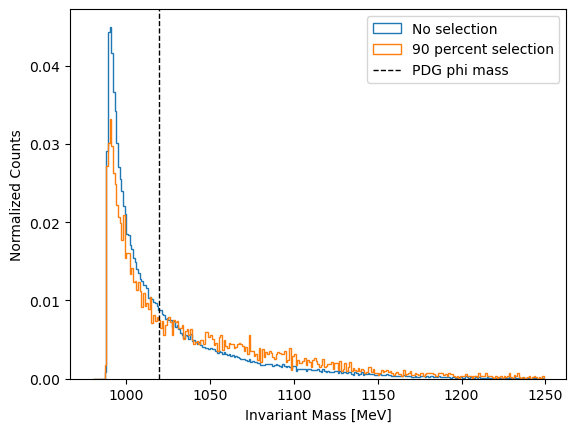

Epoch 6
-------------------------------
Classifier training loss: -13.961041
Adversary training loss: 2.335589
Classifier validation loss: -13.943677
Adversary validation loss: 2.333021
Diff score: 1.634079


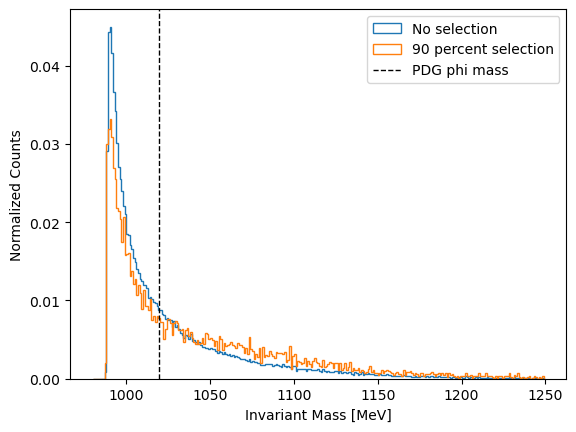

Epoch 7
-------------------------------
Classifier training loss: -13.942879
Adversary training loss: 2.333736
Classifier validation loss: -13.913695
Adversary validation loss: 2.328158
Diff score: 1.663460


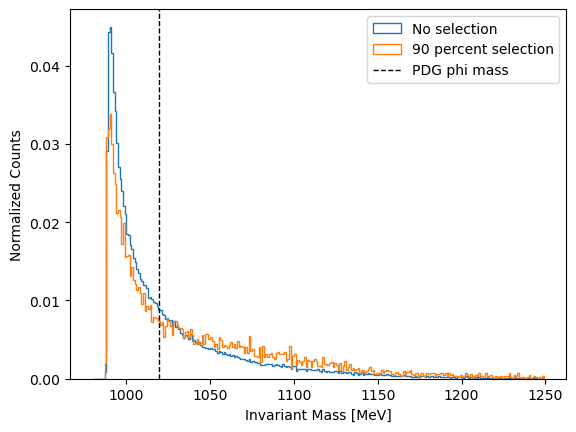

Epoch 8
-------------------------------
Classifier training loss: -13.939525
Adversary training loss: 2.331354
Classifier validation loss: -13.917546
Adversary validation loss: 2.328746
Diff score: 1.644326


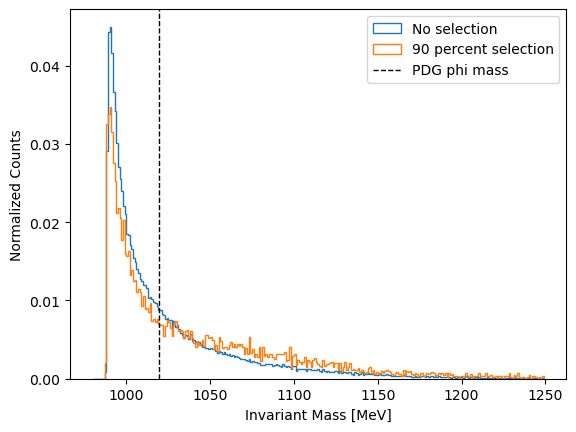

Epoch 9
-------------------------------
Classifier training loss: -13.929424
Adversary training loss: 2.330389
Classifier validation loss: -13.908329
Adversary validation loss: 2.327304
Diff score: 1.598835


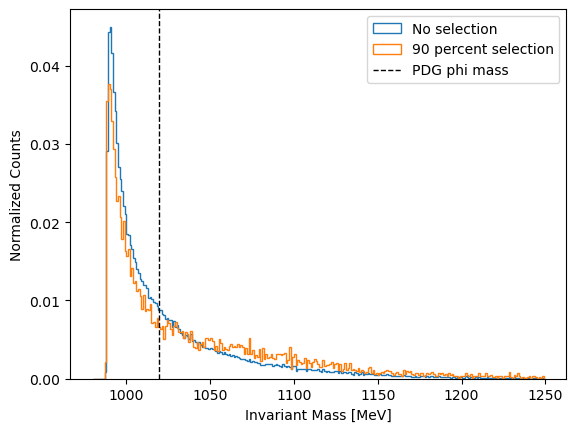

Epoch 10
-------------------------------
Classifier training loss: -13.918574
Adversary training loss: 2.328916
Classifier validation loss: -13.894601
Adversary validation loss: 2.325074
Diff score: 1.573656


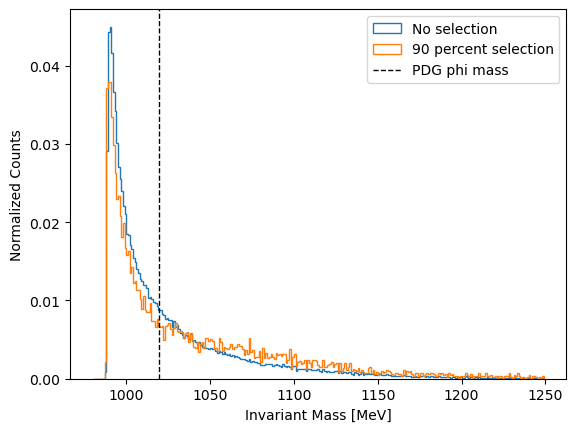

Epoch 11
-------------------------------
Classifier training loss: -13.910440
Adversary training loss: 2.327220
Classifier validation loss: -13.900940
Adversary validation loss: 2.326253
Diff score: 1.587853


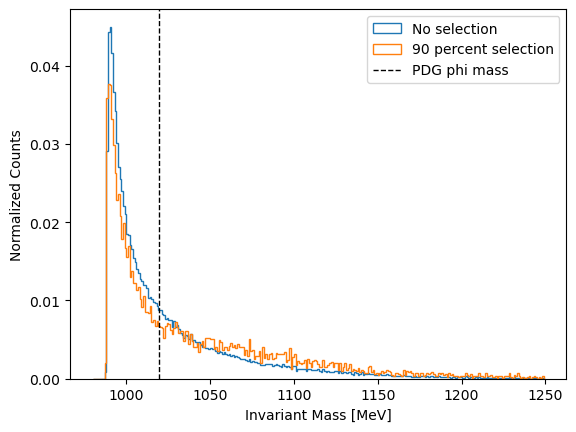

Epoch 12
-------------------------------
Classifier training loss: -13.898865
Adversary training loss: 2.326492
Classifier validation loss: -13.890516
Adversary validation loss: 2.324192
Diff score: 1.598804


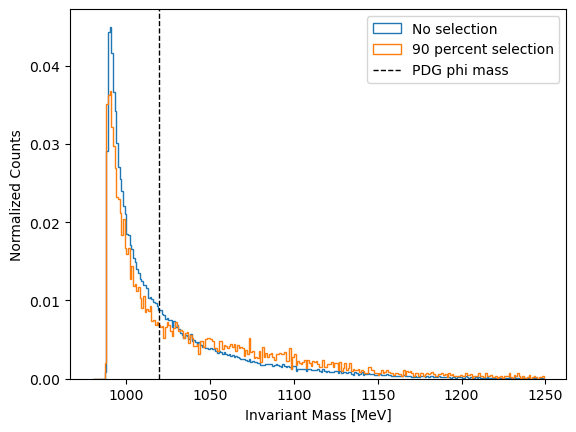

Epoch 13
-------------------------------
Classifier training loss: -13.891294
Adversary training loss: 2.324744
Classifier validation loss: -13.893407
Adversary validation loss: 2.324865
Diff score: 1.660658


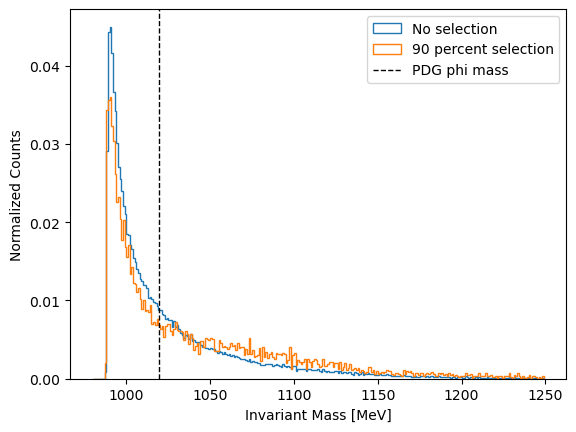

Epoch 14
-------------------------------
Classifier training loss: -13.885075
Adversary training loss: 2.323458
Classifier validation loss: -13.881829
Adversary validation loss: 2.323110
Diff score: 1.737264


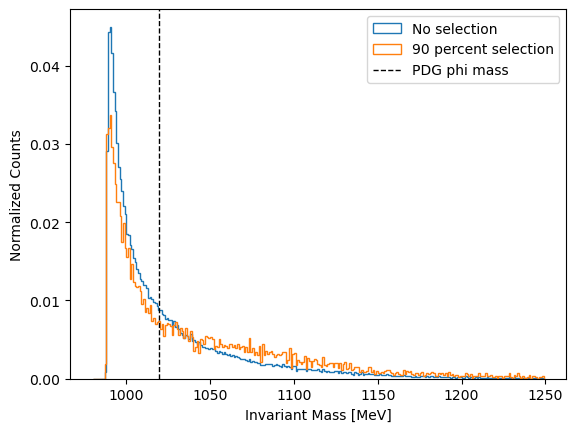

Epoch 15
-------------------------------
Classifier training loss: -13.878510
Adversary training loss: 2.322580
Classifier validation loss: -13.879870
Adversary validation loss: 2.322395
Diff score: 1.782366


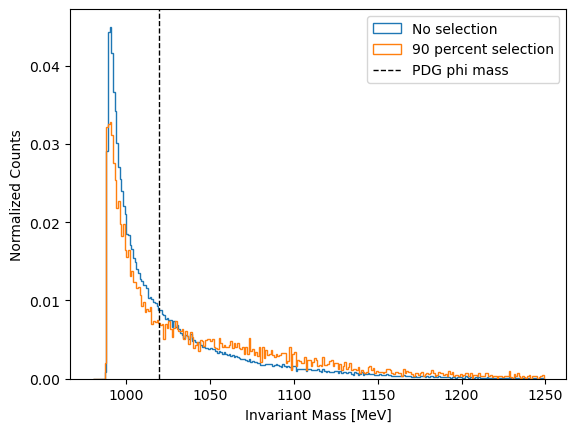

Epoch 16
-------------------------------
Classifier training loss: -13.875618
Adversary training loss: 2.321322
Classifier validation loss: -13.883417
Adversary validation loss: 2.323099
Diff score: 1.837184


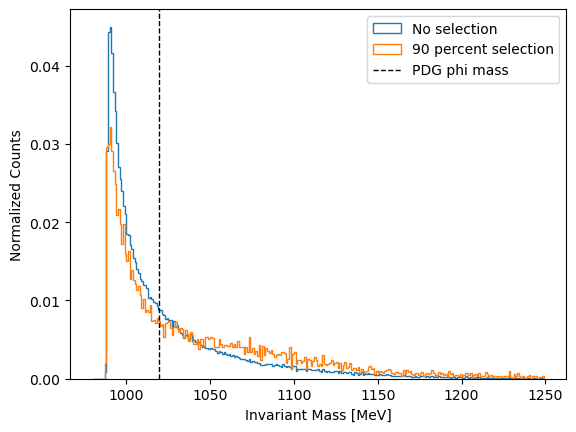

Epoch 17
-------------------------------
Classifier training loss: -13.867298
Adversary training loss: 2.320247
Classifier validation loss: -13.880140
Adversary validation loss: 2.322741
Diff score: 1.782749


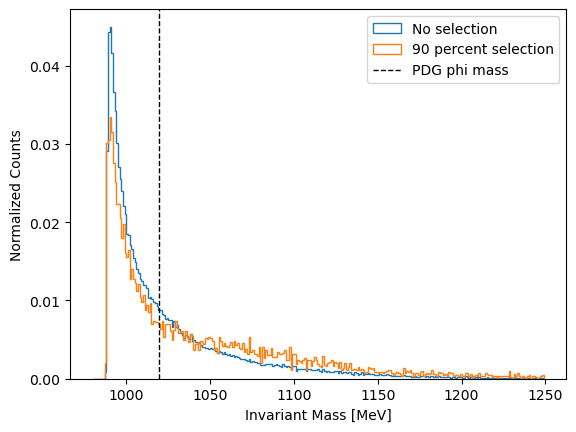

Epoch 18
-------------------------------
Classifier training loss: -13.863475
Adversary training loss: 2.320006
Classifier validation loss: -13.862107
Adversary validation loss: 2.319622
Diff score: 1.886648


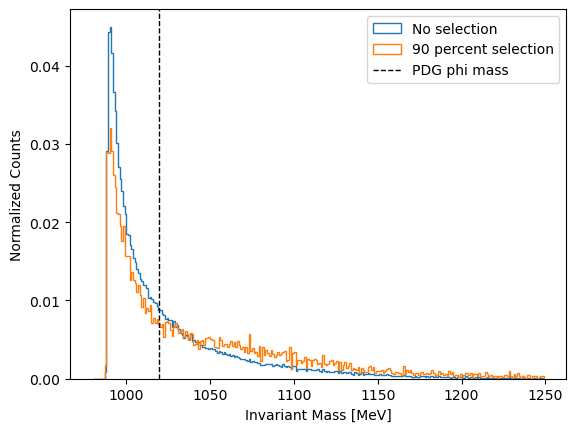

Epoch 19
-------------------------------
Classifier training loss: -13.861609
Adversary training loss: 2.319319
Classifier validation loss: -13.853781
Adversary validation loss: 2.318211
Diff score: 1.900496


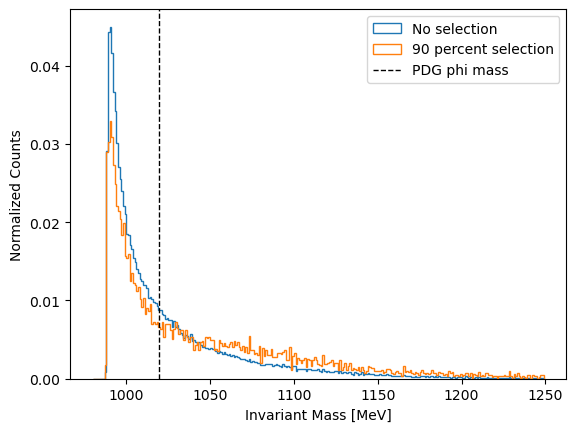

Epoch 20
-------------------------------
Classifier training loss: -13.852118
Adversary training loss: 2.318687
Classifier validation loss: -13.861300
Adversary validation loss: 2.320190
Diff score: 1.919271


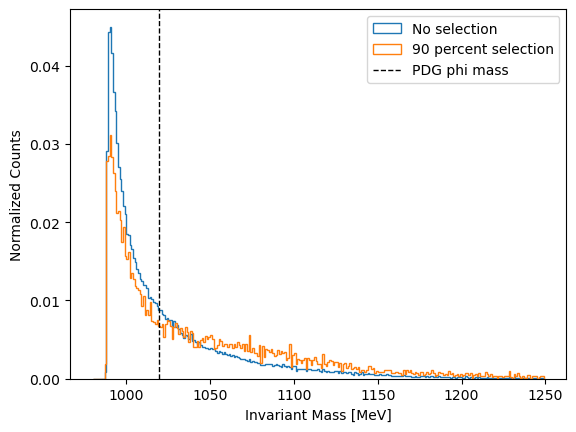

Epoch 21
-------------------------------
Classifier training loss: -13.849674
Adversary training loss: 2.318265
Classifier validation loss: -13.857819
Adversary validation loss: 2.319247
Diff score: 1.981076


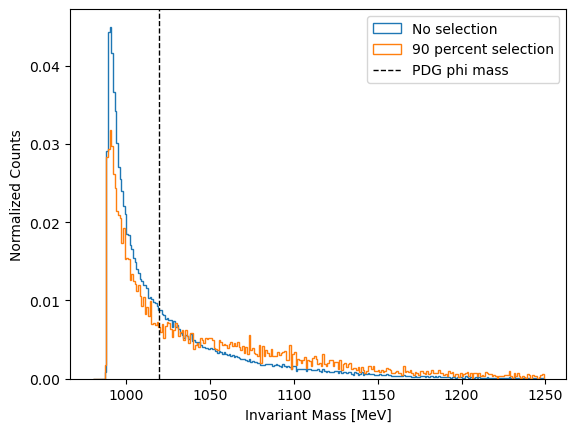

Epoch 22
-------------------------------
Classifier training loss: -13.845919
Adversary training loss: 2.317392
Classifier validation loss: -13.852703
Adversary validation loss: 2.318180
Diff score: 2.042080


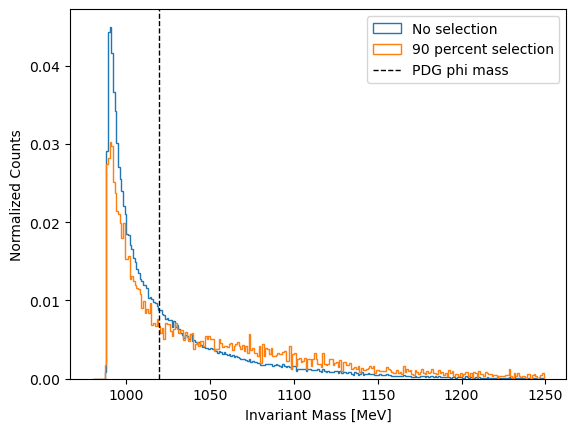

Epoch 23
-------------------------------
Classifier training loss: -13.838203
Adversary training loss: 2.316787
Classifier validation loss: -13.860383
Adversary validation loss: 2.319576
Diff score: 2.094175


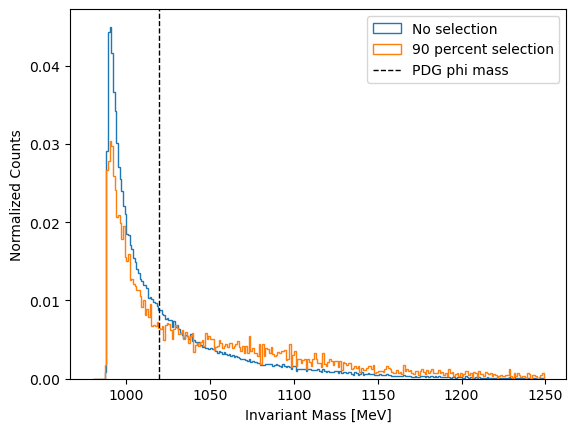

Epoch 24
-------------------------------
Classifier training loss: -13.844467
Adversary training loss: 2.316636
Classifier validation loss: -13.850755
Adversary validation loss: 2.318108
Diff score: 2.150364


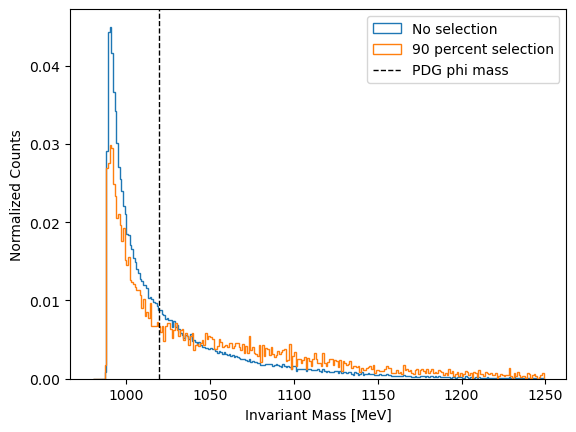

Epoch 25
-------------------------------
Classifier training loss: -13.844102
Adversary training loss: 2.316104
Classifier validation loss: -13.843354
Adversary validation loss: 2.316888
Diff score: 2.206846


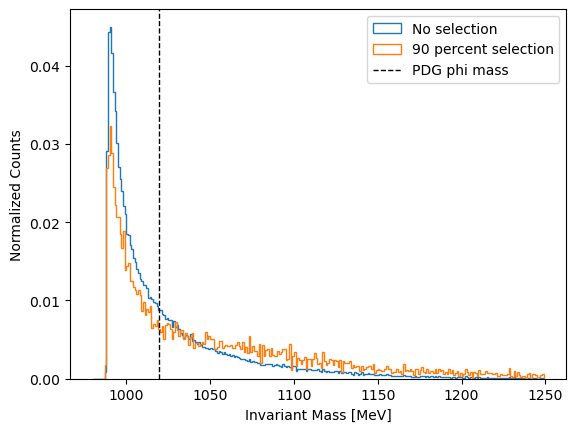

Epoch 26
-------------------------------
Classifier training loss: -13.840177
Adversary training loss: 2.315980
Classifier validation loss: -13.854568
Adversary validation loss: 2.318647
Diff score: 2.199330


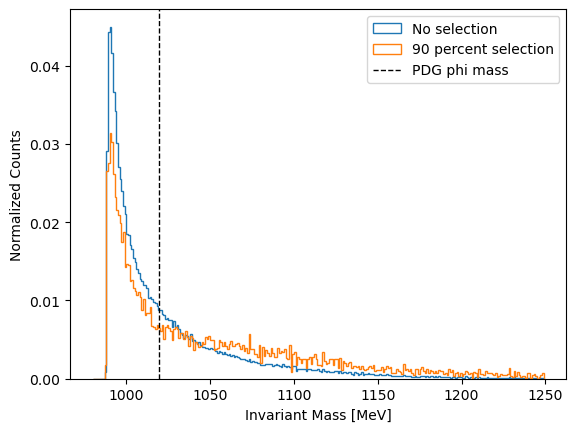

Epoch 27
-------------------------------
Classifier training loss: -13.838138
Adversary training loss: 2.315450
Classifier validation loss: -13.847998
Adversary validation loss: 2.318042
Diff score: 2.271963


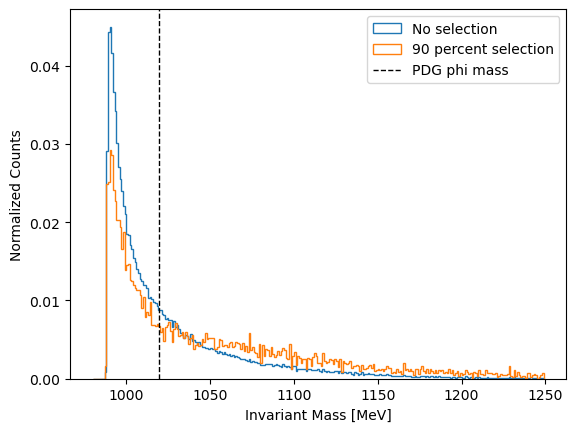

Epoch 28
-------------------------------
Classifier training loss: -13.834399
Adversary training loss: 2.315208
Classifier validation loss: -13.834187
Adversary validation loss: 2.315914
Diff score: 2.283483


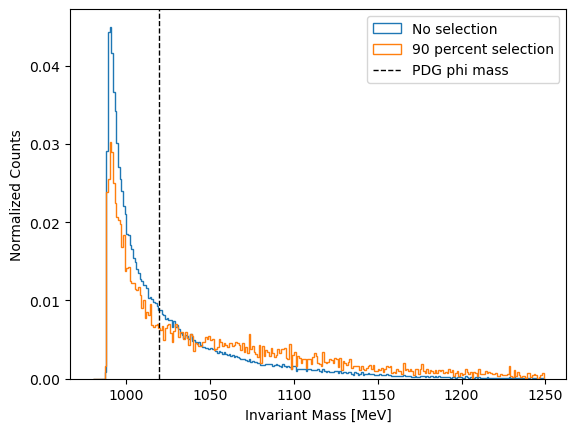

Epoch 29
-------------------------------
Classifier training loss: -13.833383
Adversary training loss: 2.315103
Classifier validation loss: -13.841116
Adversary validation loss: 2.316497
Diff score: 2.481831


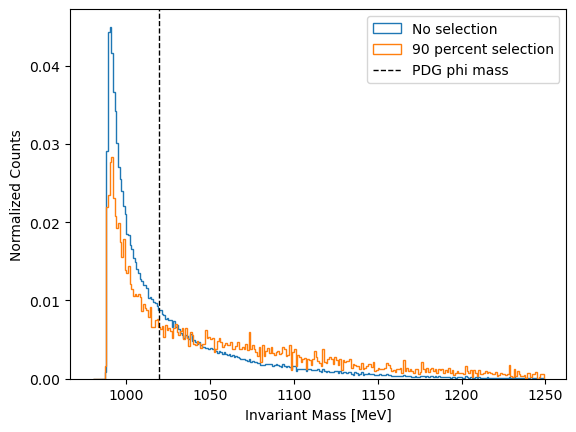

Epoch 30
-------------------------------
Classifier training loss: -13.830228
Adversary training loss: 2.315021
Classifier validation loss: -13.848286
Adversary validation loss: 2.317368
Diff score: 2.460866


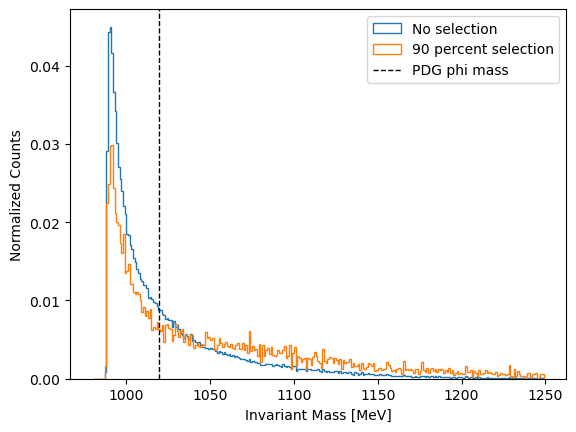

Epoch 31
-------------------------------
Classifier training loss: -13.828765
Adversary training loss: 2.314710
Classifier validation loss: -13.847055
Adversary validation loss: 2.317618
Diff score: 2.455544


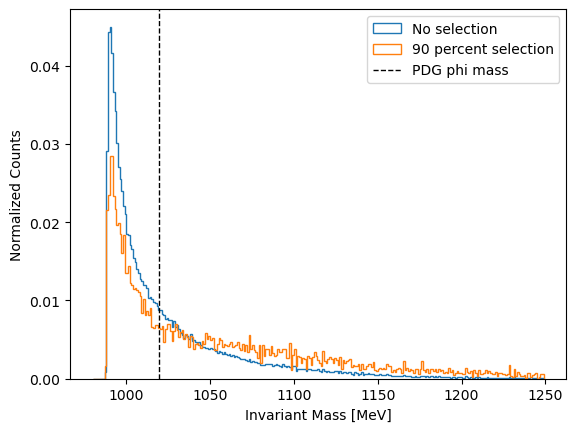

Epoch 32
-------------------------------
Classifier training loss: -13.831259
Adversary training loss: 2.314639
Classifier validation loss: -13.833832
Adversary validation loss: 2.315896
Diff score: 2.521748


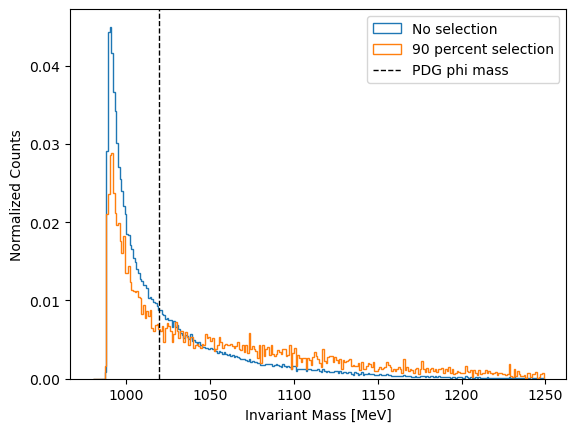

Epoch 33
-------------------------------
Classifier training loss: -13.820422
Adversary training loss: 2.314456
Classifier validation loss: -13.841475
Adversary validation loss: 2.316904
Diff score: 2.509408


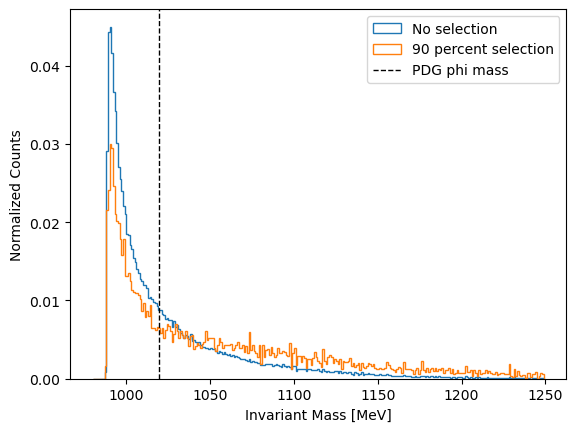

Epoch 34
-------------------------------
Classifier training loss: -13.827325
Adversary training loss: 2.314141
Classifier validation loss: -13.838180
Adversary validation loss: 2.316057
Diff score: 2.566550


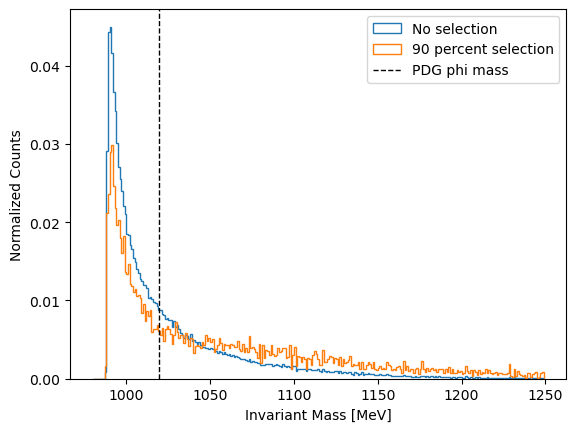

Epoch 35
-------------------------------
Classifier training loss: -13.825159
Adversary training loss: 2.314049
Classifier validation loss: -13.846734
Adversary validation loss: 2.317351
Diff score: 2.592805


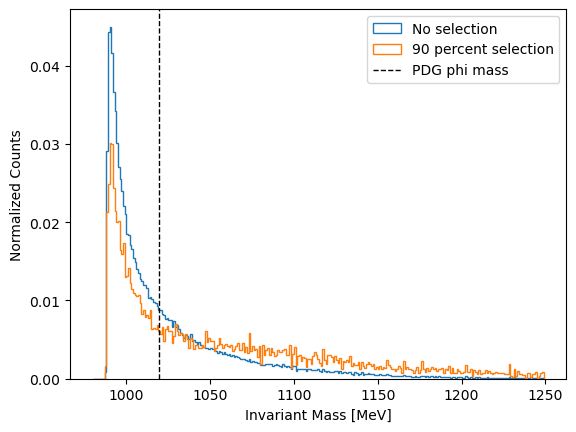

Epoch 36
-------------------------------
Classifier training loss: -13.823638
Adversary training loss: 2.313947
Classifier validation loss: -13.829281
Adversary validation loss: 2.314703
Diff score: 2.744533


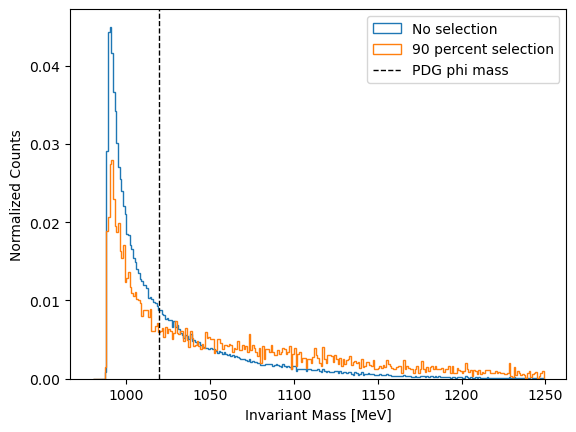

Epoch 37
-------------------------------
Classifier training loss: -13.821152
Adversary training loss: 2.313935
Classifier validation loss: -13.838745
Adversary validation loss: 2.316566
Diff score: 2.770544


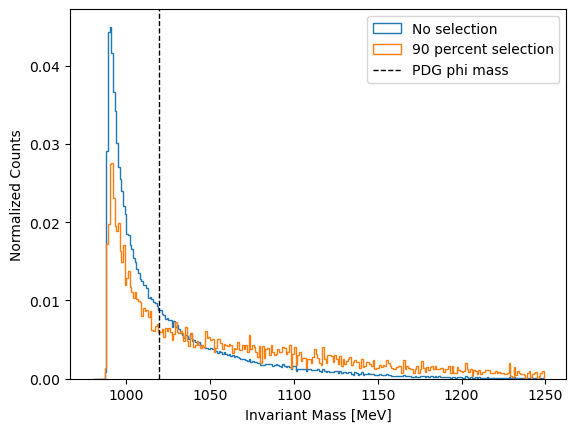

Epoch 38
-------------------------------
Classifier training loss: -13.821100
Adversary training loss: 2.314016
Classifier validation loss: -13.836027
Adversary validation loss: 2.316102
Diff score: 2.785678


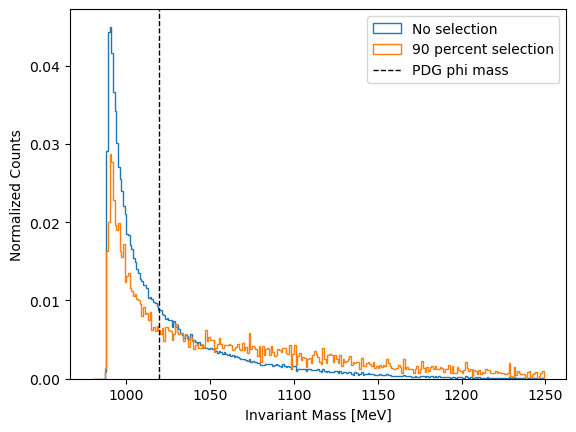

Epoch 39
-------------------------------
Classifier training loss: -13.823173
Adversary training loss: 2.314014
Classifier validation loss: -13.848996
Adversary validation loss: 2.317961
Diff score: 2.779467


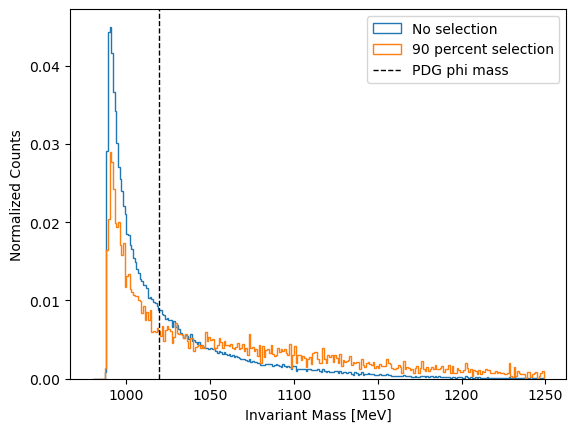

Epoch 40
-------------------------------
Classifier training loss: -13.821746
Adversary training loss: 2.313624
Classifier validation loss: -13.844140
Adversary validation loss: 2.317580
Diff score: 2.822578


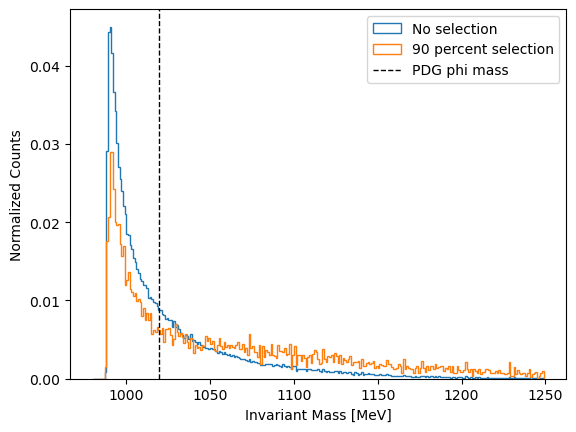

Epoch 41
-------------------------------
Classifier training loss: -13.820835
Adversary training loss: 2.313926
Classifier validation loss: -13.848204
Adversary validation loss: 2.318114
Diff score: 2.885404


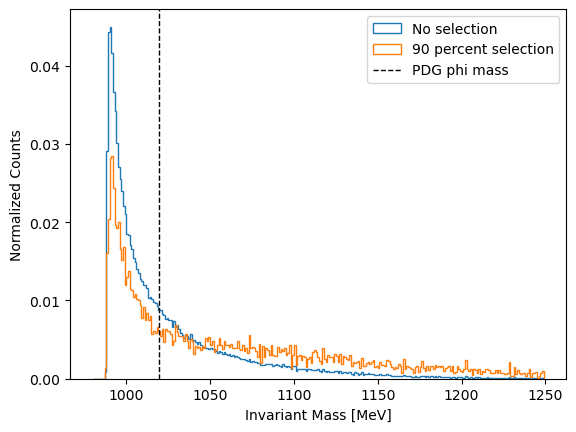

Epoch 42
-------------------------------
Classifier training loss: -13.819754
Adversary training loss: 2.313686
Classifier validation loss: -13.840867
Adversary validation loss: 2.317175
Diff score: 2.889385


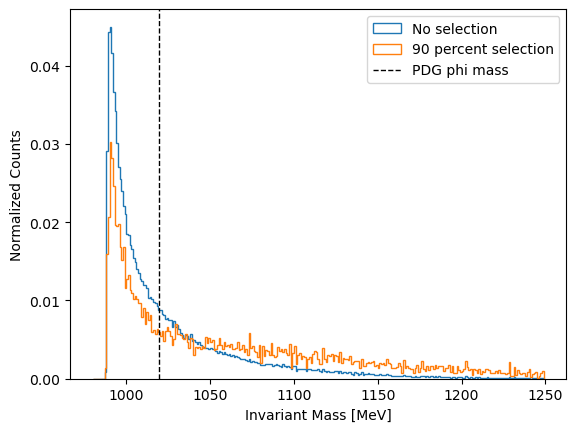

Epoch 43
-------------------------------
Classifier training loss: -13.820394
Adversary training loss: 2.313837
Classifier validation loss: -13.838947
Adversary validation loss: 2.316918
Diff score: 2.953078


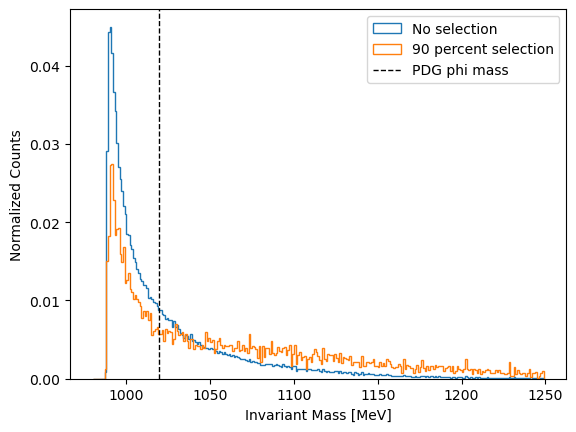

Epoch 44
-------------------------------
Classifier training loss: -13.821369
Adversary training loss: 2.313592
Classifier validation loss: -13.840418
Adversary validation loss: 2.316926
Diff score: 3.015531


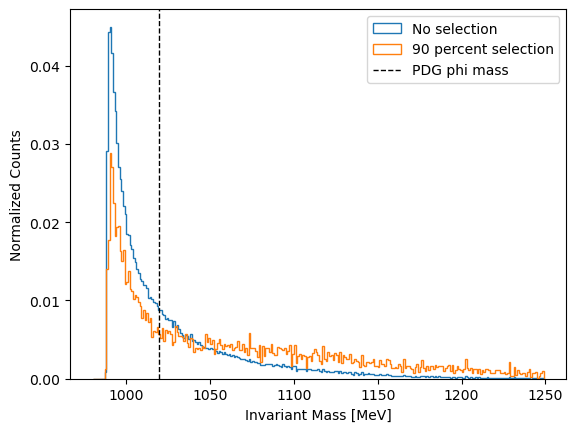

Epoch 45
-------------------------------
Classifier training loss: -13.820002
Adversary training loss: 2.313659
Classifier validation loss: -13.846124
Adversary validation loss: 2.318142
Diff score: 2.945977


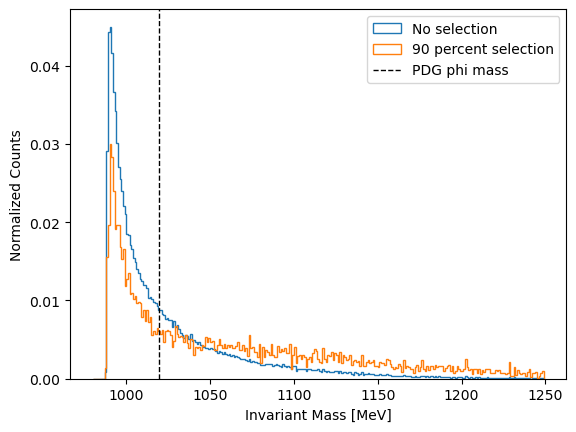

Epoch 46
-------------------------------
Classifier training loss: -13.823041
Adversary training loss: 2.313800
Classifier validation loss: -13.838474
Adversary validation loss: 2.316666
Diff score: 3.020816


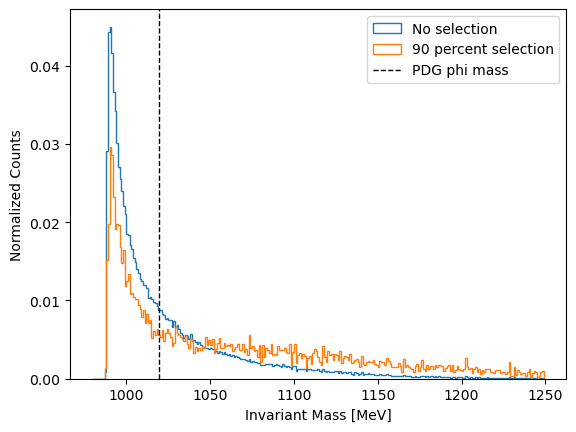

Epoch 47
-------------------------------
Classifier training loss: -13.818871
Adversary training loss: 2.313652
Classifier validation loss: -13.844106
Adversary validation loss: 2.317606
Diff score: 2.997715


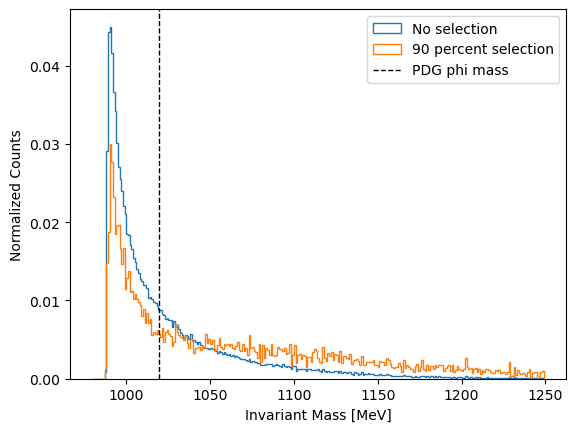

Epoch 48
-------------------------------
Classifier training loss: -13.819221
Adversary training loss: 2.313540
Classifier validation loss: -13.845230
Adversary validation loss: 2.318473
Diff score: 3.098865


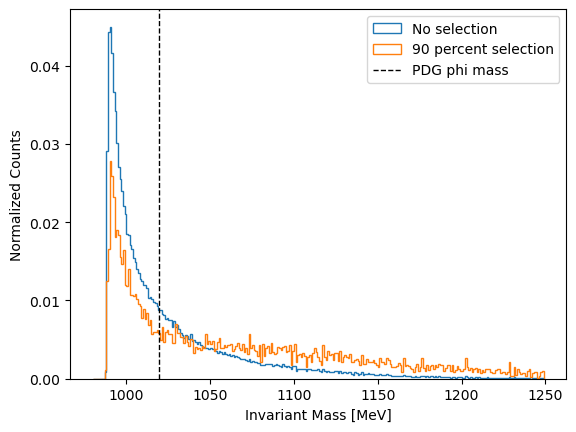

Epoch 49
-------------------------------
Classifier training loss: -13.821500
Adversary training loss: 2.313704
Classifier validation loss: -13.845885
Adversary validation loss: 2.317809
Diff score: 3.068107


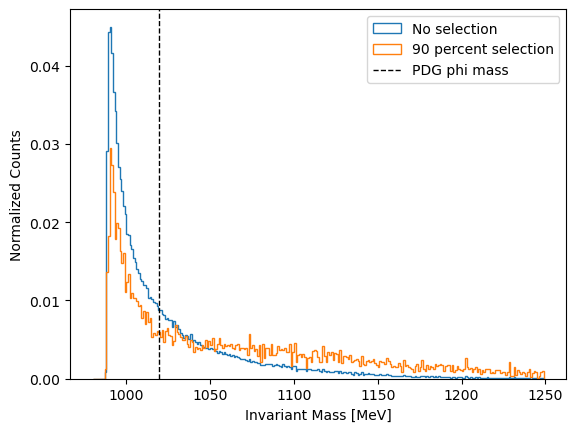

Epoch 50
-------------------------------
Classifier training loss: -13.818097
Adversary training loss: 2.313568
Classifier validation loss: -13.846611
Adversary validation loss: 2.318100
Diff score: 3.091630


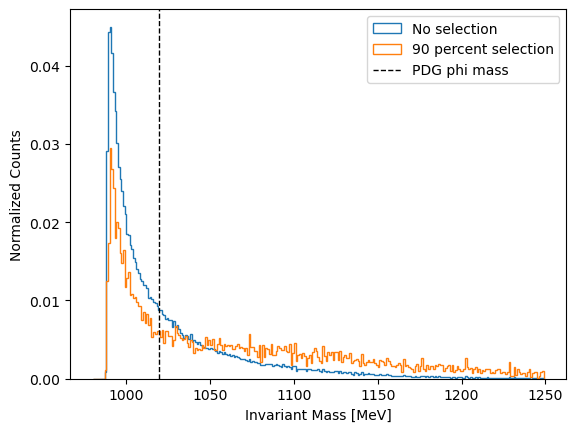

Epoch 51
-------------------------------
Classifier training loss: -13.814464
Adversary training loss: 2.313700
Classifier validation loss: -13.843015
Adversary validation loss: 2.317302
Diff score: 3.163167


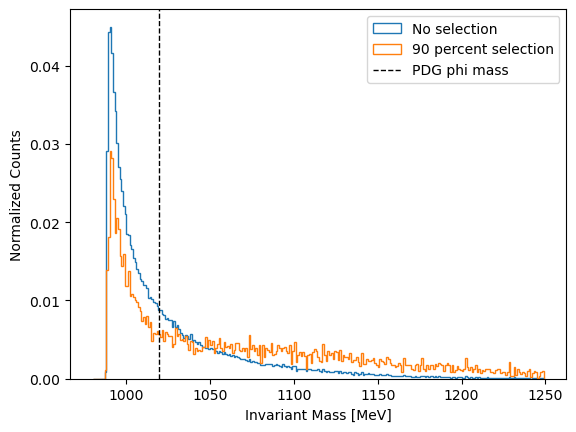

Epoch 52
-------------------------------
Classifier training loss: -13.817333
Adversary training loss: 2.313600
Classifier validation loss: -13.841516
Adversary validation loss: 2.317015
Diff score: 3.192340


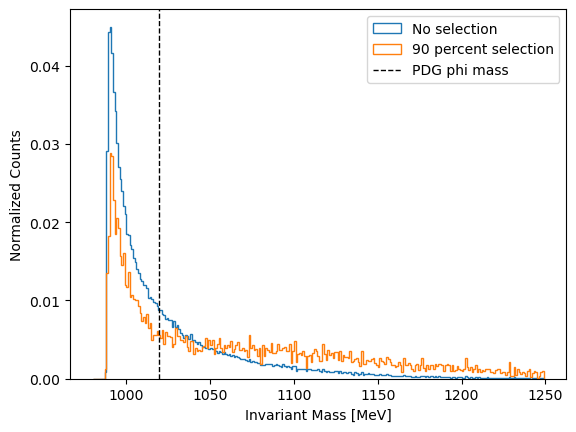

Epoch 53
-------------------------------
Classifier training loss: -13.818777
Adversary training loss: 2.313746
Classifier validation loss: -13.845135
Adversary validation loss: 2.317945
Diff score: 3.191925


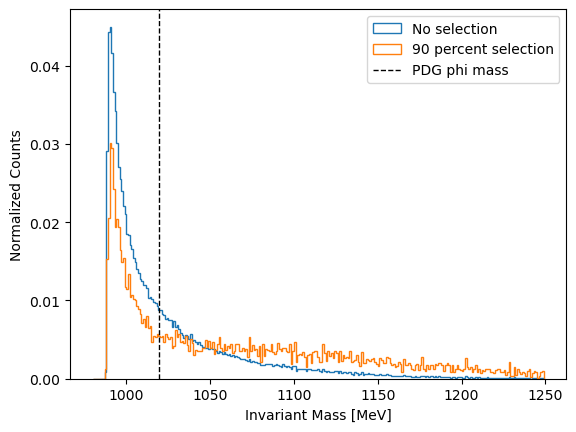

Epoch 54
-------------------------------
Classifier training loss: -13.819038
Adversary training loss: 2.313645
Classifier validation loss: -13.852608
Adversary validation loss: 2.318983
Diff score: 3.221191


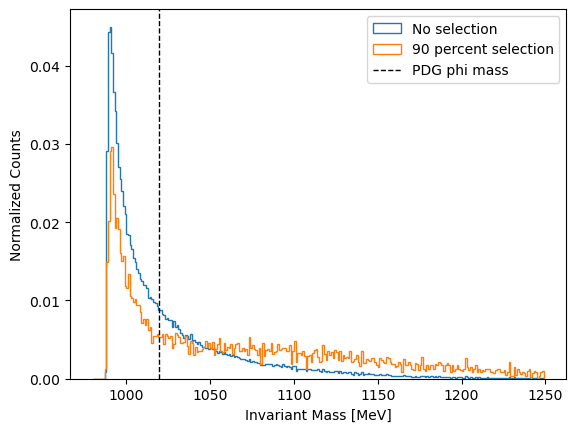

Epoch 55
-------------------------------
Classifier training loss: -13.815174
Adversary training loss: 2.313787
Classifier validation loss: -13.844638
Adversary validation loss: 2.318182
Diff score: 3.255953


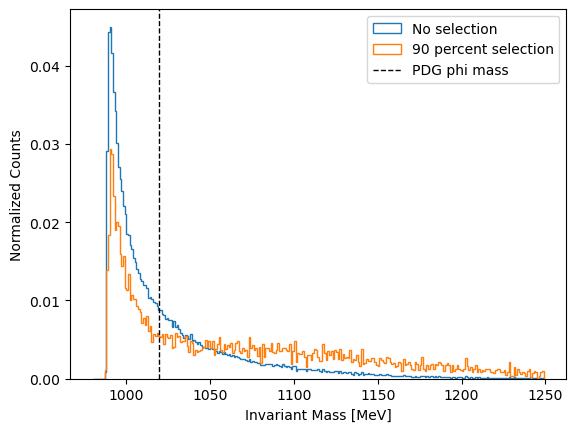

Epoch 56
-------------------------------
Classifier training loss: -13.820459
Adversary training loss: 2.313685
Classifier validation loss: -13.837131
Adversary validation loss: 2.316697
Diff score: 3.290817


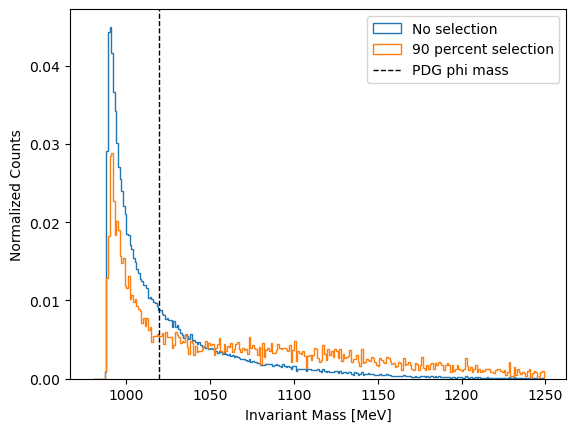

Epoch 57
-------------------------------
Classifier training loss: -13.817438
Adversary training loss: 2.313510
Classifier validation loss: -13.846206
Adversary validation loss: 2.318656
Diff score: 3.358123


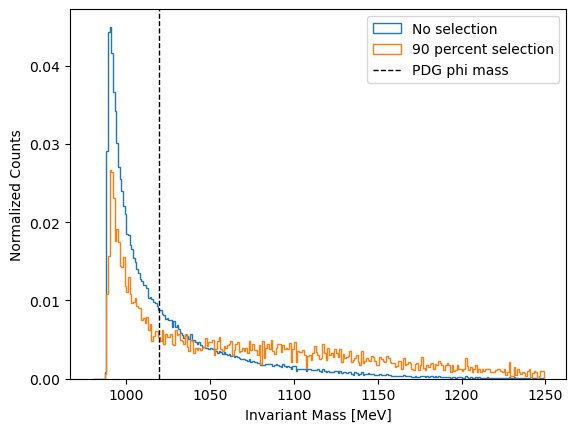

Epoch 58
-------------------------------
Classifier training loss: -13.812368
Adversary training loss: 2.313549
Classifier validation loss: -13.844147
Adversary validation loss: 2.317581
Diff score: 3.344832


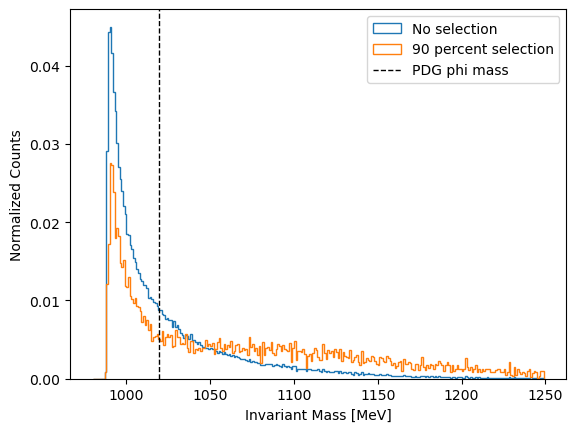

Epoch 59
-------------------------------
Classifier training loss: -13.814213
Adversary training loss: 2.313844
Classifier validation loss: -13.839145
Adversary validation loss: 2.316676
Diff score: 3.298591


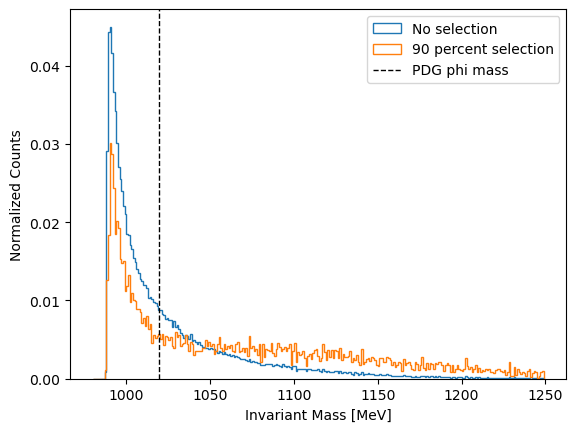

Epoch 60
-------------------------------
Classifier training loss: -13.811648
Adversary training loss: 2.313648
Classifier validation loss: -13.844335
Adversary validation loss: 2.317672
Diff score: 3.295938


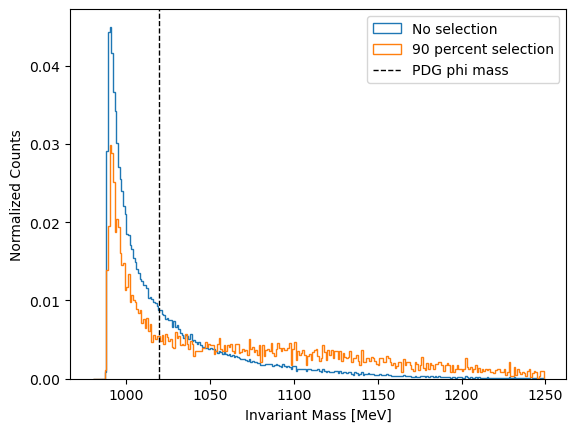

Epoch 61
-------------------------------
Classifier training loss: -13.818826
Adversary training loss: 2.313594
Classifier validation loss: -13.853116
Adversary validation loss: 2.319691
Diff score: 3.348673


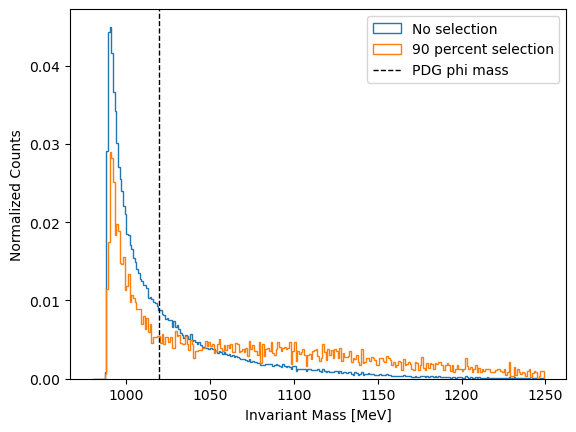

Epoch 62
-------------------------------
Classifier training loss: -13.811299
Adversary training loss: 2.313710
Classifier validation loss: -13.843707
Adversary validation loss: 2.317795
Diff score: 3.339601


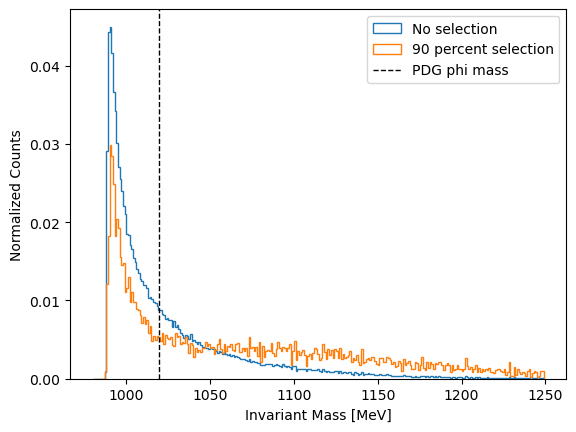

Epoch 63
-------------------------------
Classifier training loss: -13.808275
Adversary training loss: 2.313518
Classifier validation loss: -13.847907
Adversary validation loss: 2.318897
Diff score: 3.406661


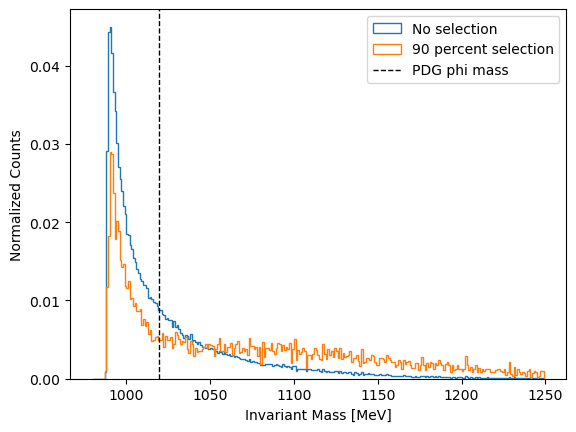

Epoch 64
-------------------------------
Classifier training loss: -13.817460
Adversary training loss: 2.313565
Classifier validation loss: -13.843449
Adversary validation loss: 2.317425
Diff score: 3.411162


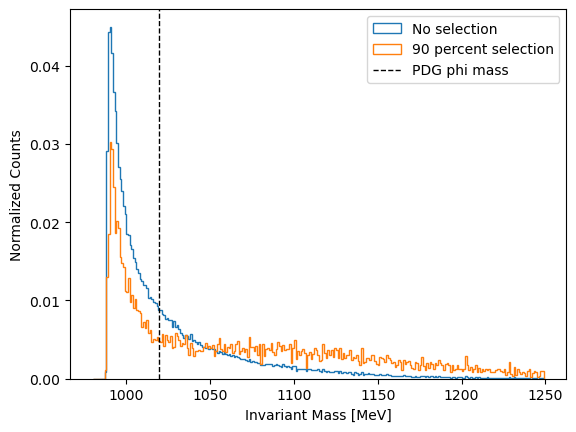

Epoch 65
-------------------------------
Classifier training loss: -13.815863
Adversary training loss: 2.313324
Classifier validation loss: -13.844323
Adversary validation loss: 2.317776
Diff score: 3.430447


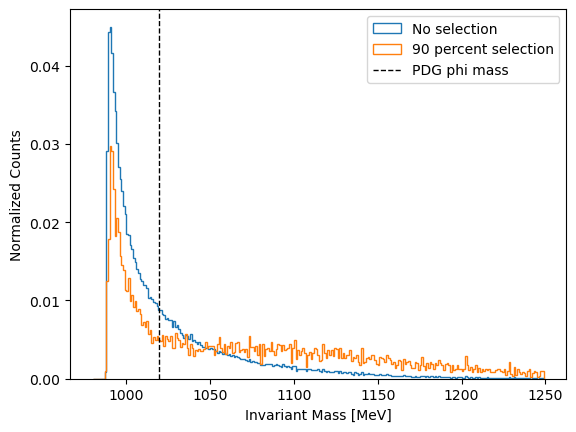

Epoch 66
-------------------------------
Classifier training loss: -13.817498
Adversary training loss: 2.313432
Classifier validation loss: -13.841653
Adversary validation loss: 2.317921
Diff score: 3.413753


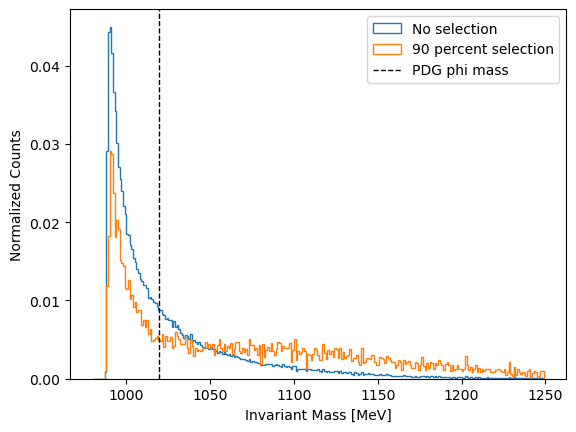

Epoch 67
-------------------------------
Classifier training loss: -13.818120
Adversary training loss: 2.313309
Classifier validation loss: -13.840047
Adversary validation loss: 2.317246
Diff score: 3.491323


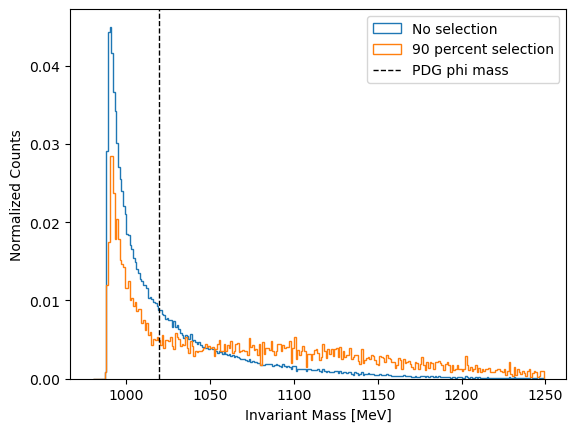

Epoch 68
-------------------------------
Classifier training loss: -13.815522
Adversary training loss: 2.313160
Classifier validation loss: -13.844220
Adversary validation loss: 2.317926
Diff score: 3.433751


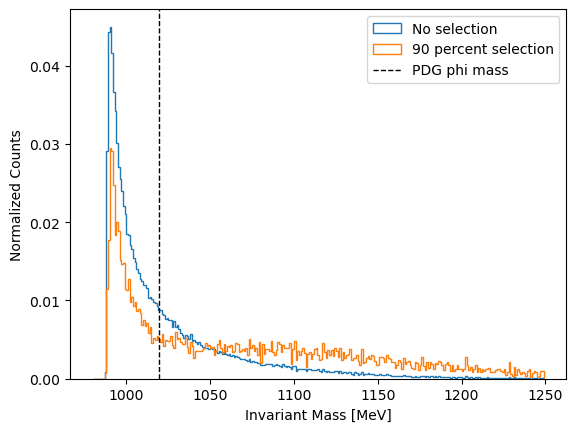

Epoch 69
-------------------------------
Classifier training loss: -13.805255
Adversary training loss: 2.313083
Classifier validation loss: -13.844594
Adversary validation loss: 2.317932
Diff score: 3.442016


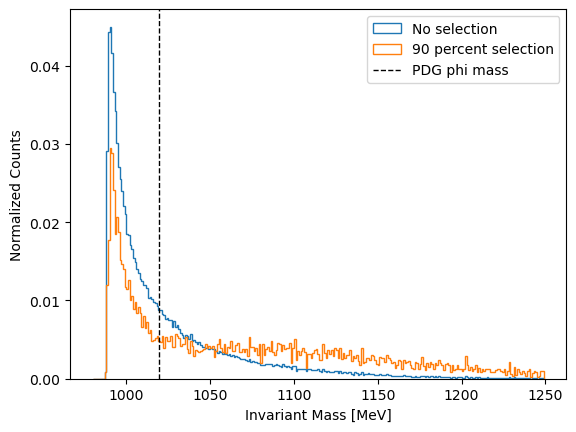

Epoch 70
-------------------------------
Classifier training loss: -13.814238
Adversary training loss: 2.313289
Classifier validation loss: -13.840215
Adversary validation loss: 2.317256
Diff score: 3.465261


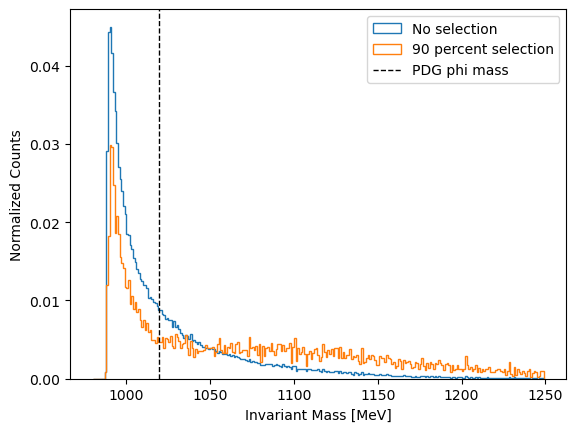

Epoch 71
-------------------------------
Classifier training loss: -13.813256
Adversary training loss: 2.313091
Classifier validation loss: -13.849911
Adversary validation loss: 2.318814
Diff score: 3.438058


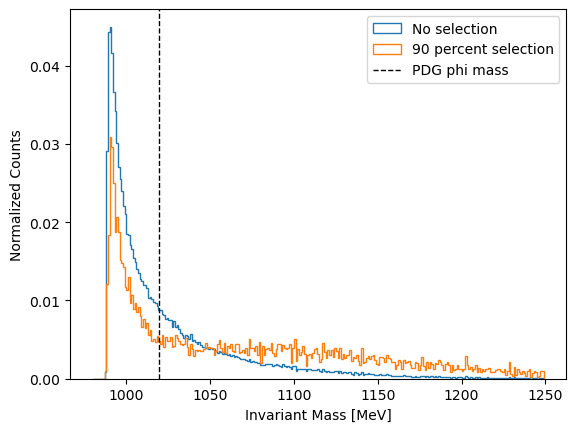

Epoch 72
-------------------------------
Classifier training loss: -13.816291
Adversary training loss: 2.313061
Classifier validation loss: -13.848587
Adversary validation loss: 2.318789
Diff score: 3.456832


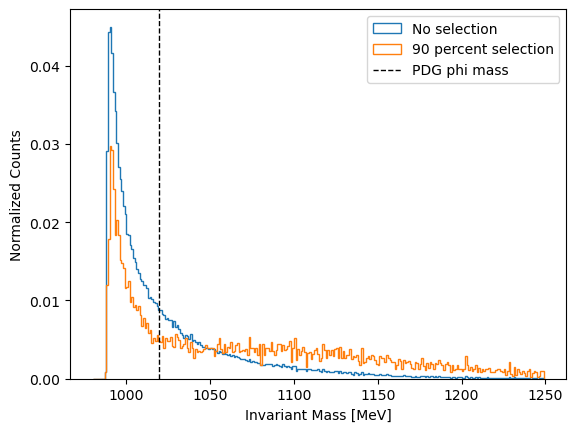

Epoch 73
-------------------------------
Classifier training loss: -13.811951
Adversary training loss: 2.313377
Classifier validation loss: -13.848808
Adversary validation loss: 2.318862
Diff score: 3.438113


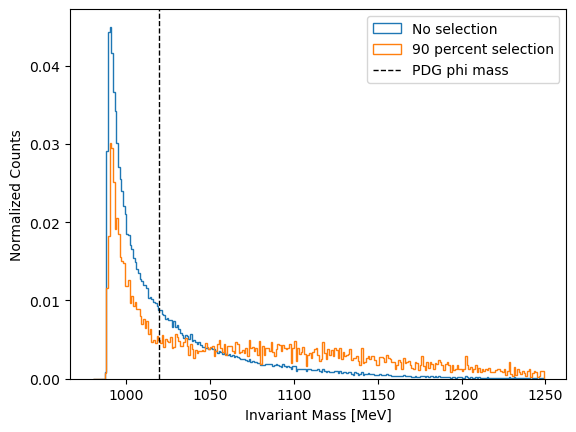

Epoch 74
-------------------------------
Classifier training loss: -13.813746
Adversary training loss: 2.312929
Classifier validation loss: -13.844015
Adversary validation loss: 2.318170
Diff score: 3.358318


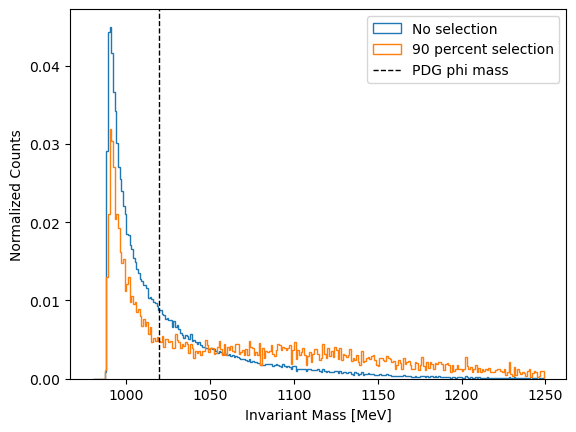

Epoch 75
-------------------------------
Classifier training loss: -13.815624
Adversary training loss: 2.313039
Classifier validation loss: -13.844298
Adversary validation loss: 2.318265
Diff score: 3.406888


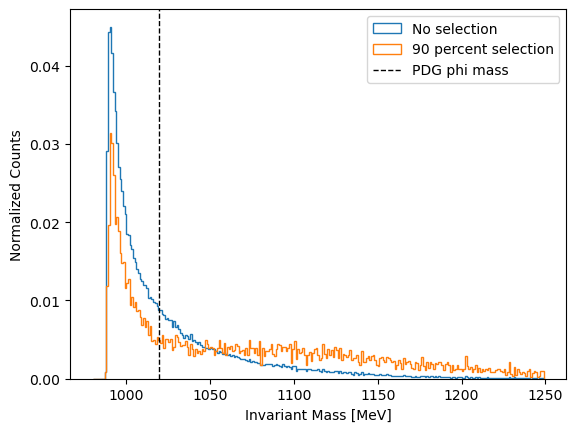

Epoch 76
-------------------------------
Classifier training loss: -13.812282
Adversary training loss: 2.312887
Classifier validation loss: -13.838586
Adversary validation loss: 2.317334
Diff score: 3.456758


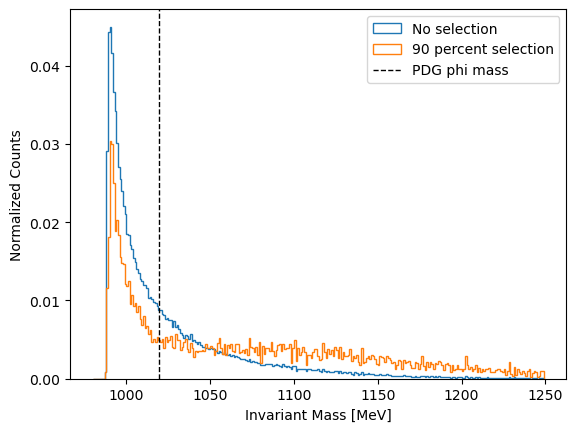

Epoch 77
-------------------------------
Classifier training loss: -13.814233
Adversary training loss: 2.312653
Classifier validation loss: -13.843477
Adversary validation loss: 2.318266
Diff score: 3.454859


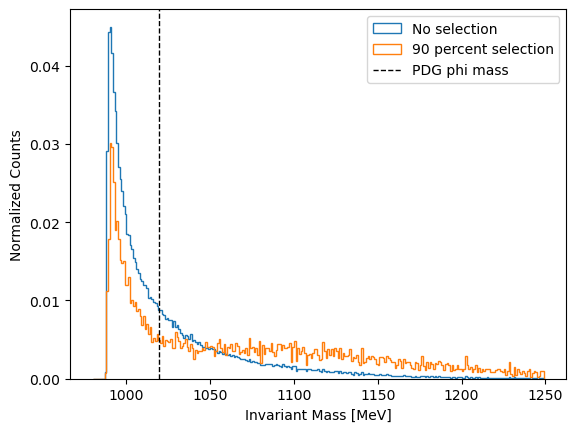

Epoch 78
-------------------------------
Classifier training loss: -13.807018
Adversary training loss: 2.312802
Classifier validation loss: -13.839670
Adversary validation loss: 2.317209
Diff score: 3.539644


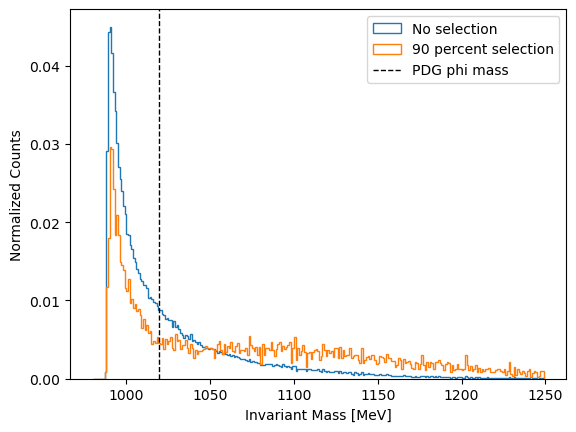

Epoch 79
-------------------------------
Classifier training loss: -13.812258
Adversary training loss: 2.312564
Classifier validation loss: -13.841035
Adversary validation loss: 2.317621
Diff score: 3.455717


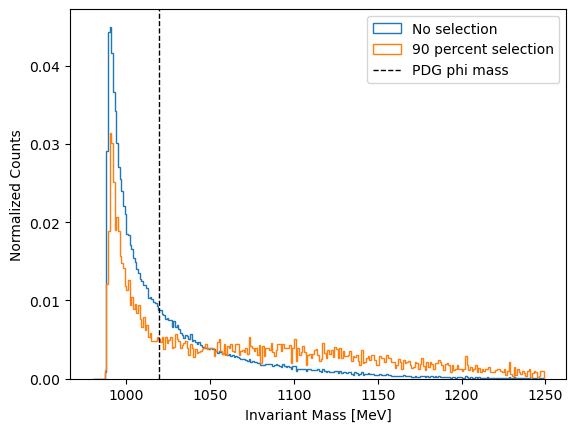

Epoch 80
-------------------------------
Classifier training loss: -13.812755
Adversary training loss: 2.312827
Classifier validation loss: -13.836342
Adversary validation loss: 2.317109
Diff score: 3.497344


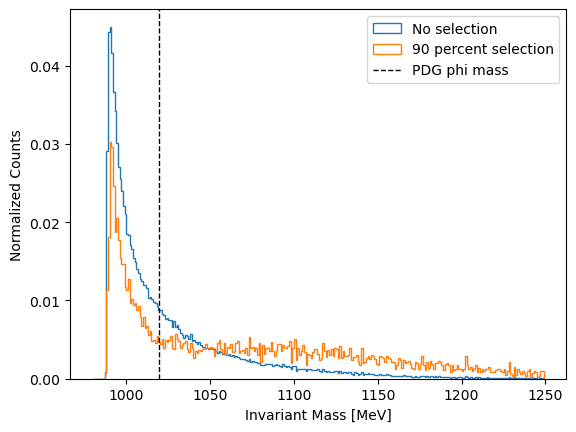

Epoch 81
-------------------------------
Classifier training loss: -13.808409
Adversary training loss: 2.312730
Classifier validation loss: -13.841108
Adversary validation loss: 2.317218
Diff score: 3.507711


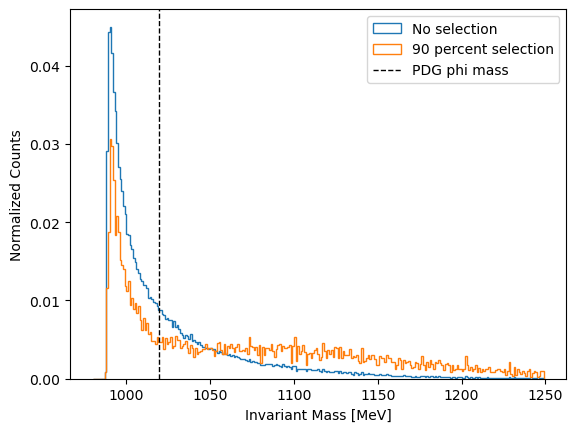

Epoch 82
-------------------------------
Classifier training loss: -13.814483
Adversary training loss: 2.312572
Classifier validation loss: -13.844003
Adversary validation loss: 2.317635
Diff score: 3.547982


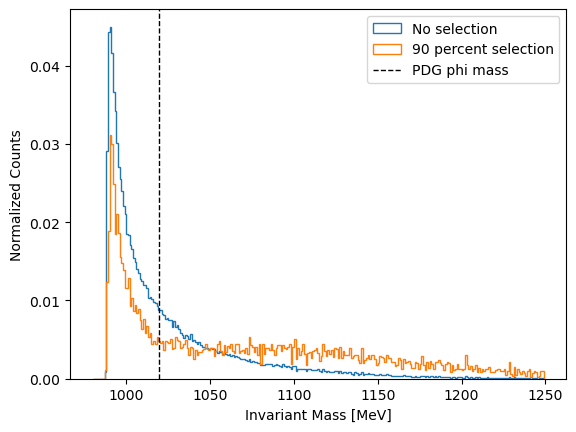

Epoch 83
-------------------------------
Classifier training loss: -13.807337
Adversary training loss: 2.312577
Classifier validation loss: -13.829393
Adversary validation loss: 2.316053
Diff score: 3.510572


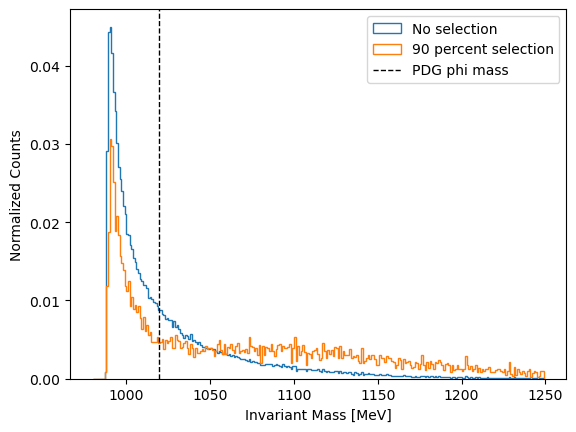

Epoch 84
-------------------------------
Classifier training loss: -13.810374
Adversary training loss: 2.312775
Classifier validation loss: -13.837907
Adversary validation loss: 2.316878
Diff score: 3.520069


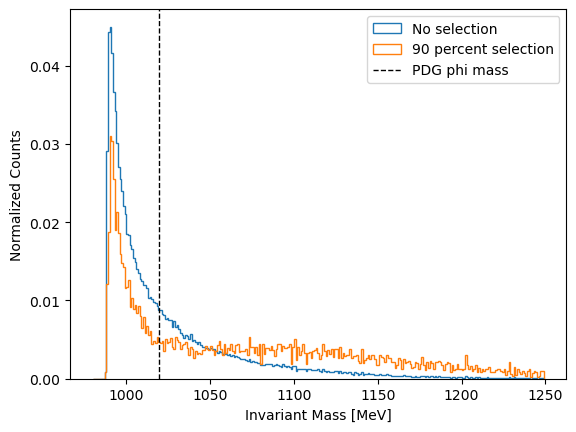

Epoch 85
-------------------------------
Classifier training loss: -13.811702
Adversary training loss: 2.312267
Classifier validation loss: -13.832508
Adversary validation loss: 2.316546
Diff score: 3.476561


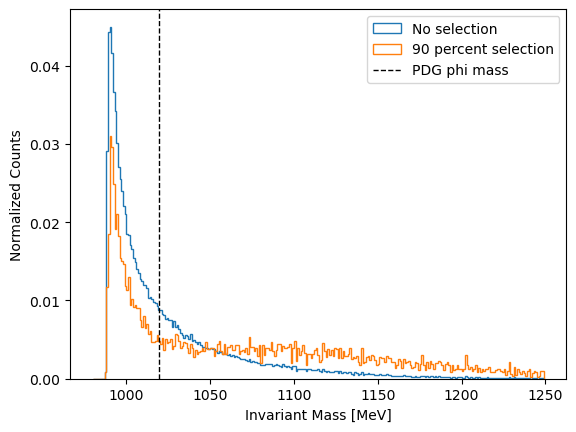

Epoch 86
-------------------------------
Classifier training loss: -13.813391
Adversary training loss: 2.312608
Classifier validation loss: -13.841036
Adversary validation loss: 2.317734
Diff score: 3.503383


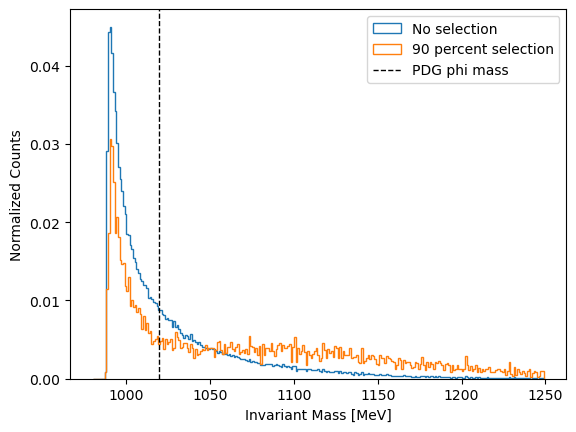

Epoch 87
-------------------------------
Classifier training loss: -13.810713
Adversary training loss: 2.312439
Classifier validation loss: -13.835433
Adversary validation loss: 2.316344
Diff score: 3.521380


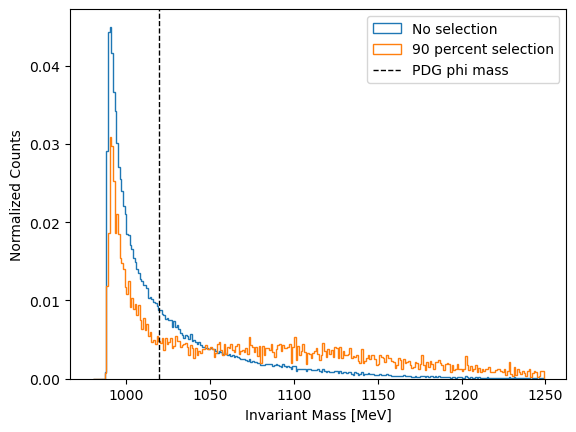

Epoch 88
-------------------------------
Classifier training loss: -13.807405
Adversary training loss: 2.312413
Classifier validation loss: -13.836537
Adversary validation loss: 2.317398
Diff score: 3.529600


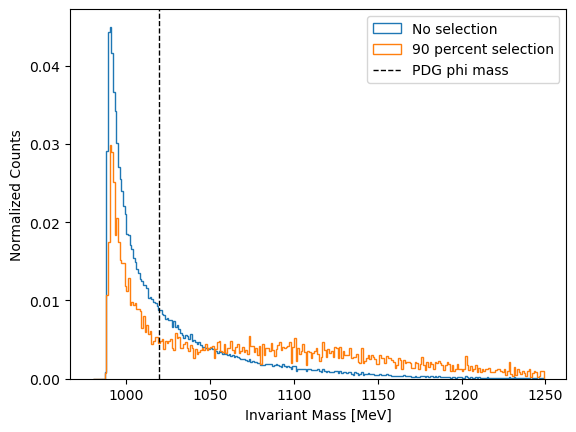

Epoch 89
-------------------------------
Classifier training loss: -13.805684
Adversary training loss: 2.312213
Classifier validation loss: -13.841617
Adversary validation loss: 2.317402
Diff score: 3.545873


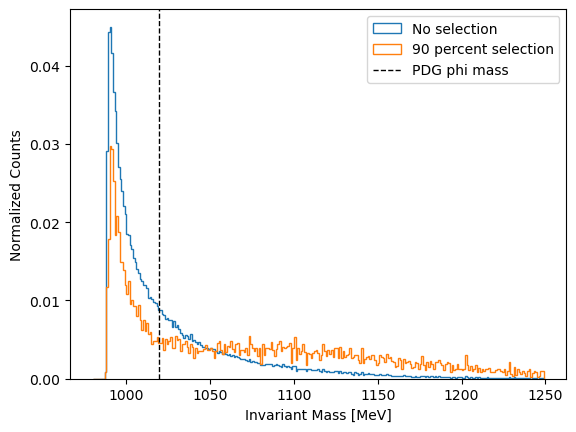

Epoch 90
-------------------------------
Classifier training loss: -13.809596
Adversary training loss: 2.312335
Classifier validation loss: -13.840664
Adversary validation loss: 2.317444
Diff score: 3.542557


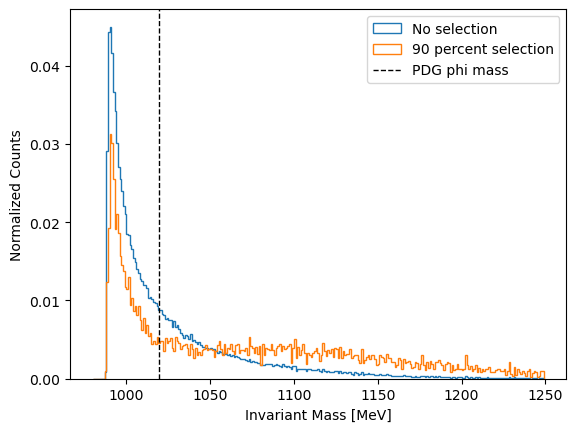

Epoch 91
-------------------------------
Classifier training loss: -13.808747
Adversary training loss: 2.312123
Classifier validation loss: -13.829982
Adversary validation loss: 2.316005
Diff score: 3.480448


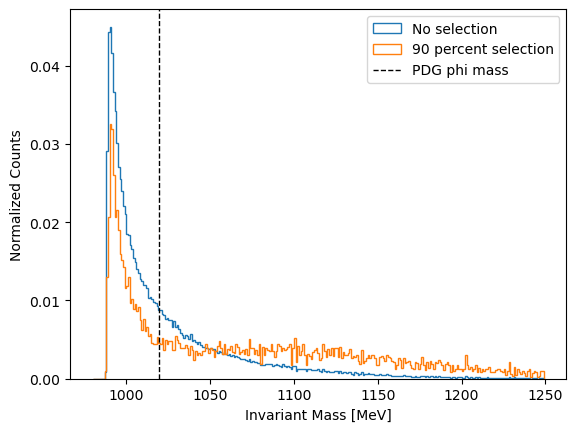

Epoch 92
-------------------------------
Classifier training loss: -13.808944
Adversary training loss: 2.312251
Classifier validation loss: -13.839945
Adversary validation loss: 2.317425
Diff score: 3.513733


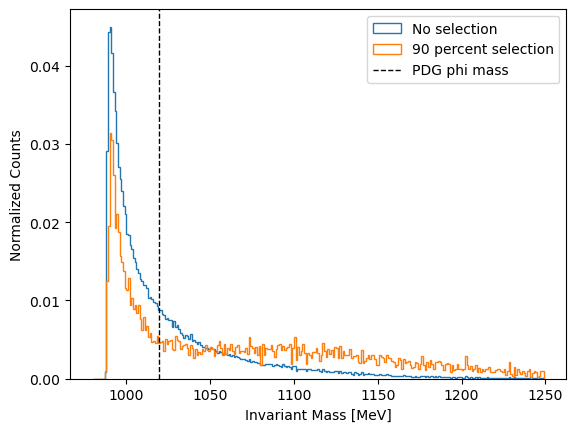

Epoch 93
-------------------------------
Classifier training loss: -13.805644
Adversary training loss: 2.312212
Classifier validation loss: -13.829106
Adversary validation loss: 2.315675
Diff score: 3.534696


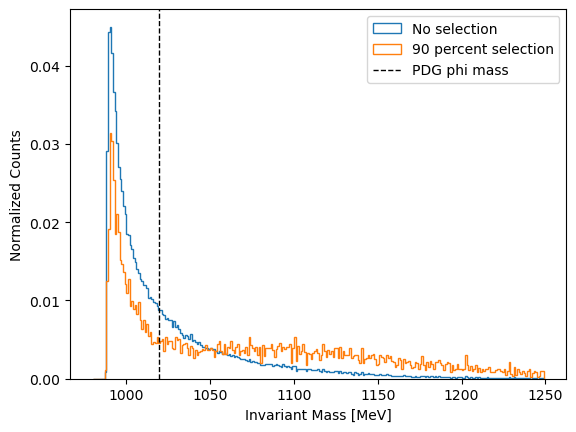

Epoch 94
-------------------------------
Classifier training loss: -13.796277
Adversary training loss: 2.312178
Classifier validation loss: -13.833541
Adversary validation loss: 2.316123
Diff score: 3.591873


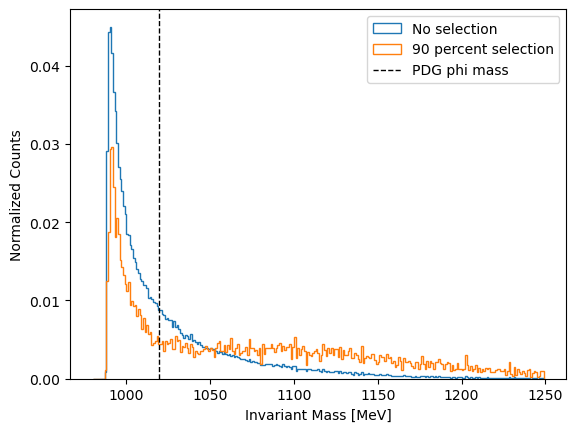

Epoch 95
-------------------------------
Classifier training loss: -13.805489
Adversary training loss: 2.312068
Classifier validation loss: -13.832852
Adversary validation loss: 2.317141
Diff score: 3.536073


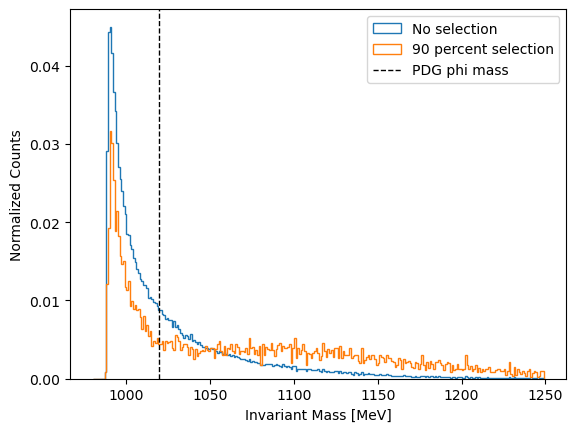

Epoch 96
-------------------------------
Classifier training loss: -13.806058
Adversary training loss: 2.312024
Classifier validation loss: -13.833204
Adversary validation loss: 2.316303
Diff score: 3.507422


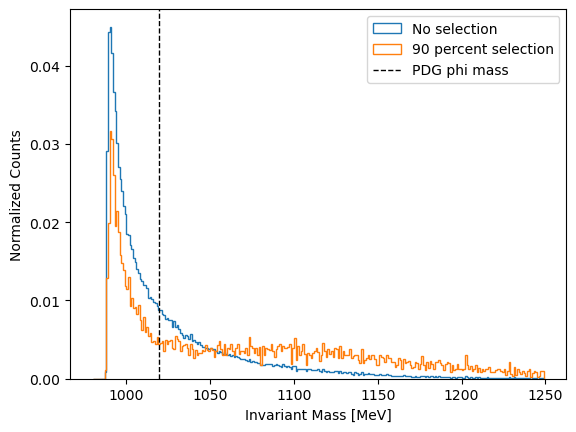

Epoch 97
-------------------------------
Classifier training loss: -13.805231
Adversary training loss: 2.311838
Classifier validation loss: -13.833457
Adversary validation loss: 2.316204
Diff score: 3.545011


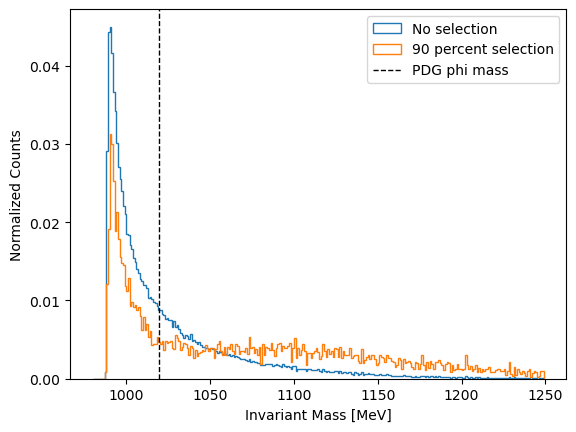

Epoch 98
-------------------------------
Classifier training loss: -13.808709
Adversary training loss: 2.311984
Classifier validation loss: -13.835070
Adversary validation loss: 2.316541
Diff score: 3.518127


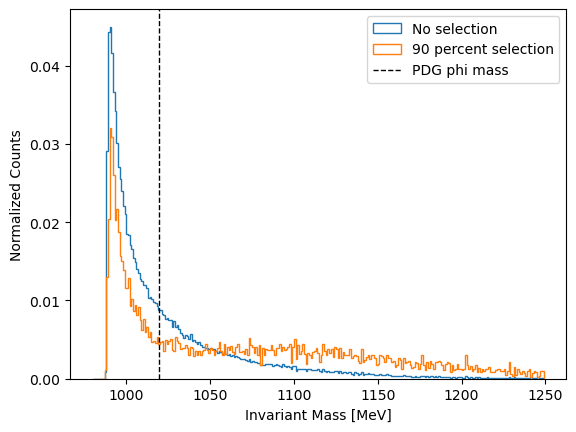

Epoch 99
-------------------------------
Classifier training loss: -13.808272
Adversary training loss: 2.311606
Classifier validation loss: -13.831547
Adversary validation loss: 2.316099
Diff score: 3.535056


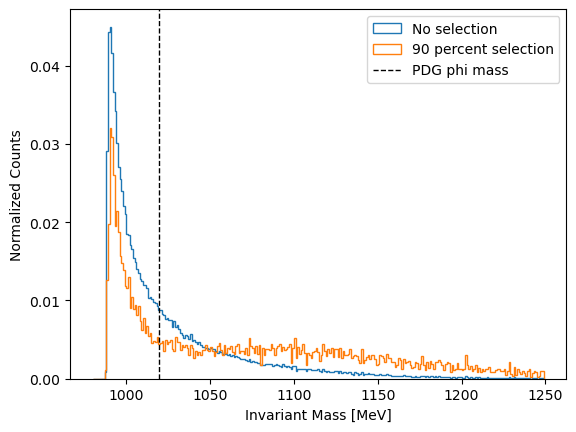

Epoch 100
-------------------------------
Classifier training loss: -13.808398
Adversary training loss: 2.311913
Classifier validation loss: -13.838259
Adversary validation loss: 2.317232
Diff score: 3.543268


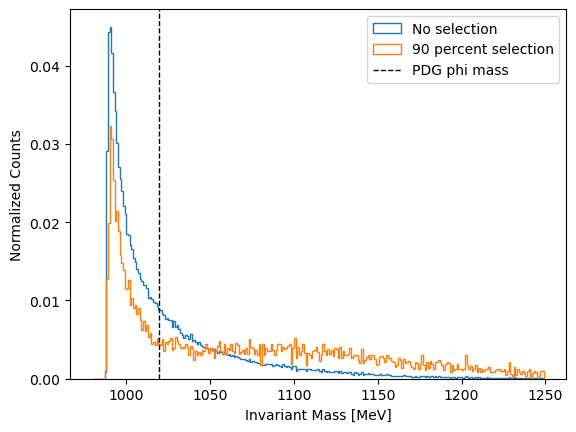

Done!


In [19]:


Training_losses_clas = np.array([])
Training_losses_adv = np.array([])
Validation_losses_clas = np.array([])
Validation_losses_adv = np.array([])
diff_scores = np.array([])


epochs = 100
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    
    # Train adversary and classifier
    E_clas_training_loss , E_adv_training_loss = mytools.train_full_orig(train_full_loader, final_classifier, final_adv, full_loss, lambda_, criterion_adv, optimizer_clas, optimizer_adv, scheduler_clas, scheduler_adv, 8, device, grad_clip = False)
    Training_losses_clas = np.append(Training_losses_clas, E_clas_training_loss)
    Training_losses_adv = np.append(Training_losses_adv, E_adv_training_loss)

    # Get validation losses
    E_clas_val_loss, E_adv_val_loss = mytools.validate_full(val_full_loader, final_classifier, final_adv, full_loss, lambda_, criterion_adv, device)
    Validation_losses_clas = np.append(Validation_losses_clas, E_clas_val_loss)
    Validation_losses_adv = np.append(Validation_losses_adv, E_adv_val_loss)

    # Get the diff_score
    df_test["Class_adv"] = mytools.test_clas(test_loader, final_classifier, device)
    df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
    per = np.percentile(df_bkg['Class_adv'],90)
    df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
    x1 = 1000*df_bkg.InvM.values
    x2 = 1000*df_cut.InvM.values
    diff_scores = np.append(diff_scores, mytools.get_diff_score(x1,x2) )

    print(f"Diff score: {diff_scores[-1]:>7f}")

    plt.figure()
    plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
    plt.hist(1000*df_cut.InvM, bins=np.arange(980,1250,1), histtype='step', label= '90 percent selection', density=True)
    plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
    plt.xlabel('Invariant Mass [MeV]')
    plt.ylabel('Normalized Counts')
    plt.legend()
    plt.show()

    # Keep a running copy of the model with the lowest loss
    if diff_scores[-1] == np.min(diff_scores):
        final_clas_adv = copy.deepcopy(final_classifier)
        final_adv_adv = copy.deepcopy(final_adv)

            
print("Done!")

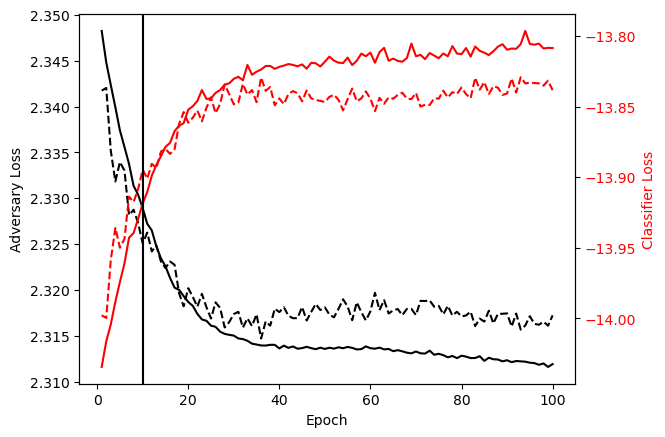

In [20]:
# Training Losses

fig, ax1 = plt.subplots()

best_epoch = np.argmin(diff_scores)+1



ax1.plot(np.arange(len(Training_losses_adv))+1, Training_losses_adv, 'k-', label='Training Adversary')
ax1.plot(np.arange(len(Validation_losses_adv))+1, Validation_losses_adv, 'k--', label='Validation Adversary')

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Adversary Loss', color='k')
ax1.tick_params(axis='y', labelcolor='k')

ax2 = ax1.twinx()

ax2.plot(np.arange(len(Training_losses_clas))+1, Training_losses_clas, 'r-', label='Training Classifier')
ax2.plot(np.arange(len(Validation_losses_clas))+1, Validation_losses_clas, 'r--', label='Validation Classifier')
ax2.axvline(best_epoch,label="Final model stopped here",color='k')

ax2.set_ylabel('Classifier Loss', color='r')
ax2.tick_params(axis='y', labelcolor='r')



Text(0.5, 0, 'Epoch')

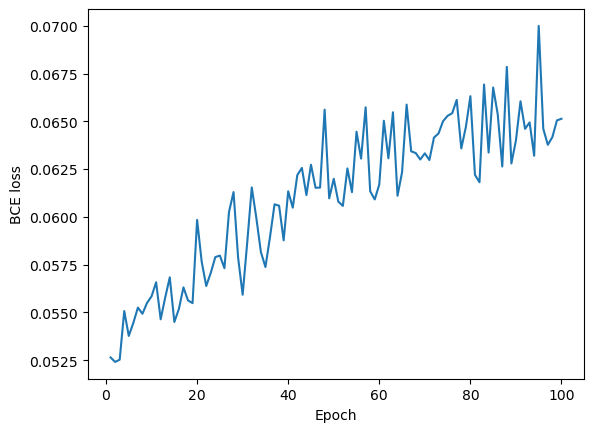

In [21]:
Validation_losses_clas+lambda_*Validation_losses_adv

plt.plot(np.arange(len(Training_losses_adv))+1, Validation_losses_clas+lambda_*Validation_losses_adv)
plt.ylabel("BCE loss")
plt.xlabel('Epoch')

## Test adversarially trained models

Test AUROC: 0.9957


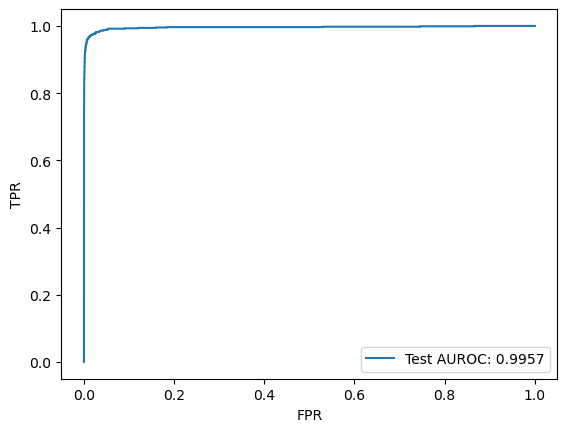

In [22]:
# Now test the pretrained model
test_pred = mytools.test_clas(test_loader, final_clas_adv, device)
test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

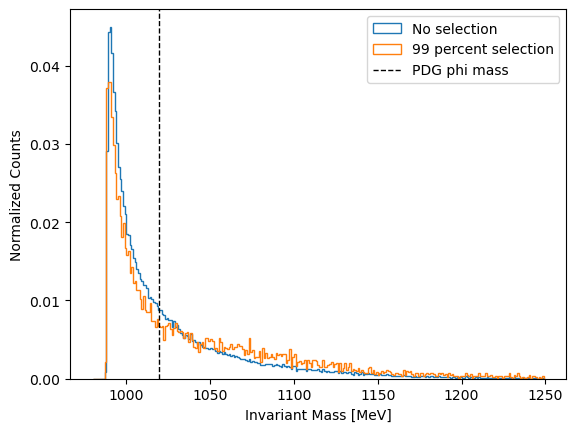

In [23]:
df_test["Class_adv"] = test_pred
df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
per = np.percentile(df_bkg['Class_adv'],90)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals = 1000*df_cut.InvM

plt.figure()
plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label= '99 percent selection', density=True)
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

In [24]:

x1 = 1000* df_bkg.InvM.values
x2 = 1000*df_cut.InvM.values

N, edges = np.histogram(x1, bins=np.arange(980,1250,1), density=False)
M, edges = np.histogram(x2, bins=np.arange(980,1250,1), density=False)

N2 = N[(N > 0) & (M > 0)]
M2 = M[(N > 0) & (M > 0)]

diff_score = np.mean(np.abs(N2/np.sum(N)-M2/np.sum(M)) / (np.sqrt(N2)/np.sum(N) + np.sqrt(M2)/np.sum(M) ))

print(diff_score)

N = len(df_test.loc[ ((df_test.type == 'tritrig') | (df_test.type == 'wab')) & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per ) ] )
S = len(df_test.loc[ (df_test.type == 'phiKK') & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per )  ] )

print(S/N)

1.2948982229194137
0.5331582403151675


Test AUROC: 0.9945


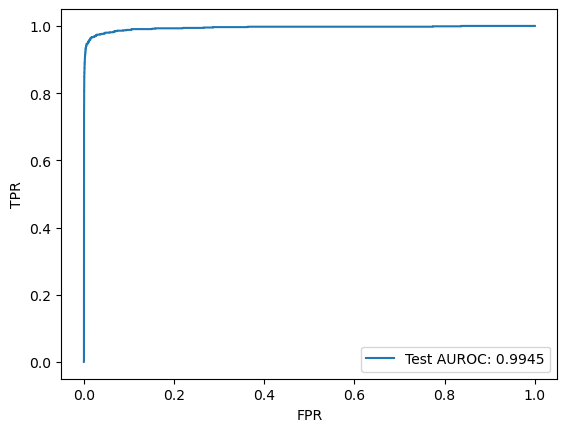

In [25]:
# Now test the pretrained model
test_pred = mytools.test_clas(test_loader, final_classifier, device)
test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

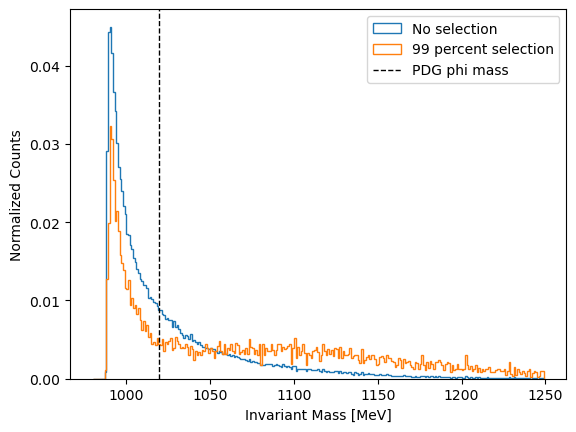

In [34]:
df_test["Class_adv"] = test_pred
df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
per = np.percentile(df_bkg['Class_adv'],90)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals = 1000*df_cut.InvM

plt.figure()
plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label= '99 percent selection', density=True)
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

In [27]:

x1 = 1000* df_bkg.InvM.values
x2 = 1000*df_cut.InvM.values

N, edges = np.histogram(x1, bins=np.arange(980,1250,1), density=False)
M, edges = np.histogram(x2, bins=np.arange(980,1250,1), density=False)

N2 = N[(N > 0) & (M > 0)]
M2 = M[(N > 0) & (M > 0)]

diff_score = np.mean(np.abs(N2/np.sum(N)-M2/np.sum(M)) / (np.sqrt(N2)/np.sum(N) + np.sqrt(M2)/np.sum(M) ))

print(diff_score)

N = len(df_test.loc[ ((df_test.type == 'tritrig') | (df_test.type == 'wab')) & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per ) ] )
S = len(df_test.loc[ (df_test.type == 'phiKK') & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per )  ] )

print(S/N)

2.990806277551216
0.8023833167825224


In [28]:
# Save the adversarially trained models
#torch.save(final_clas_adv.state_dict(), "/Users/mghrear/data/ML_data/patch/classifier_adv_2021_v9_pass5_run"+str(run)+"_limited.pt")
#torch.save(final_adv_adv.state_dict(), "/Users/mghrear/data/ML_data/patch/adversary_adv_2021_v9_pass5_run"+str(run)+"_limited.pt")